# Datos del alumno

**Nombre**: Lino

**Apellidos**: Bossio

# Sprint 3 - Métodos de *ensemble* sobre árboles de decisión para explicar la rotación de empleados

El objetivo del proyecto sigue siendo predecir si un trabajador va a abandonar la empresa o no (variable `left`).

En el **sprint 2** cambiamos a un modelo de caja blanca -el árbol de decisión- y el cliente quedó satisfecho con la
explicación. Ahora nos pide **seguir por esa vía intentando mejorar los resultados**, y la forma natural de hacerlo
sin abandonar los árboles es combinarlos: un *ensemble* mantiene el árbol como modelo base, pero sustituye el voto
de uno solo por el de cientos de ellos.

La idea de fondo es el **compromiso sesgo-varianza**. El árbol individual del sprint 2 tenía un problema conocido:
*varianza alta* (cambiar unas pocas observaciones reorganiza el árbol entero). Las dos familias de ensembles atacan
el problema por lados opuestos:

* **Bagging** (*bootstrap aggregating*): entrena muchos árboles **profundos e independientes** sobre remuestreos del
  conjunto de entrenamiento y promedia sus votos. Cada árbol tiene poco sesgo y mucha varianza; al promediar, la
  varianza se reduce y el sesgo se mantiene. `RandomForest` añade además aleatoriedad en la elección de atributos
  para **descorrelacionar** los árboles, que es lo que hace que el promedio funcione mejor.
* **Boosting**: entrena árboles **pequeños y secuenciales**, donde cada uno se especializa en los errores del
  anterior. Cada árbol es un modelo con mucho sesgo y poca varianza; la suma reduce el sesgo. A cambio, si se
  encadenan demasiados, el ensemble acaba sobreajustando.

En la **parte opcional** (sección 5) comprobamos empíricamente que esto es así, midiendo por separado el sesgo y la
varianza de cada modelo.

**Contenido del notebook**

| Sección | Contenido |
|---|---|
| 0 | Configuración, carga de datos, función de evaluación y **modelos de referencia del sprint 2** |
| 1 | **Ensembles de Bagging**: `BaggingClassifier` (2 configuraciones) y `RandomForestClassifier` (2 configuraciones) |
| 2 | **Ensembles de Boosting**: `AdaBoostClassifier` (2 configuraciones) y `GradientBoostingClassifier` (2 configuraciones) |
| 3 | **Comparación y discusión**: identificación del mejor ensemble por poder predictivo |
| 4 | **Variables más relevantes** del modelo: importancia por impureza, por permutación y coherencia con el negocio |
| 5 | **Parte opcional**: ensembles con un modelo base distinto del árbol y descomposición **sesgo-varianza** |
| 6 | Conclusiones |

## 0. Configuración del entorno

In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score,
                             roc_curve,
                             precision_recall_curve,
                             average_precision_score,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                             classification_report)
from sklearn.model_selection import (cross_val_score,
                                     GridSearchCV,
                                     validation_curve,
                                     StratifiedKFold)
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_sample_weight

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

%matplotlib inline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

Y las librerías específicas de este sprint: el árbol de decisión (modelo base) y los *ensembles* que lo combinan.

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (BaggingClassifier,
                              RandomForestClassifier,
                              AdaBoostClassifier,
                              GradientBoostingClassifier)
from sklearn.inspection import permutation_importance

> *Nota sobre `XGBoost` y `CatBoost`*: el material de clase incluye ejemplos con estas dos librerías, pero ninguna
> de las dos está instalada en el entorno en el que se ha ejecutado este notebook. El enunciado no las exige -pide
> ensembles "de los vistos en clase" con árboles como modelo base, y `GradientBoostingClassifier` de `scikit-learn`
> cubre exactamente la misma familia de *gradient boosting*-, así que la comparativa se hace con `scikit-learn`.
> En Colab bastaría con descomentar la celda siguiente para añadirlas.

In [3]:
## Si se quiere ampliar la comparativa con XGBoost / CatBoost, descomentar:
#!pip install xgboost catboost
#from xgboost import XGBClassifier
#from catboost import CatBoostClassifier

### 0.1 Carga de las matrices de train y test

Seguimos trabajando con **las mismas particiones del sprint 1** (`X_train.npy`, `X_test.npy`, `y_train.npy`,
`y_test.npy`) que ya usamos en el sprint 2. Es imprescindible para que la comparación "árbol individual vs
ensemble" sea limpia: si cambiásemos la partición no sabríamos si la mejora viene del ensemble o de los datos.

La celda busca primero los ficheros en local (por si se ejecuta desde el repositorio) y, si no los encuentra, los
descarga de Google Drive como en la plantilla original.

In [4]:
FICHEROS = ["X_train.npy", "X_test.npy", "y_train.npy", "y_test.npy", "Rotacion_empleados.csv"]

# Rutas candidatas: directorio actual, ./data y la carpeta data_proyecto/data del repositorio
CANDIDATAS = [Path("."), Path("data"), Path("data_proyecto/data"),
              Path("../data_proyecto/data"), Path("../data")]

ENLACES = {
    "y_train.npy":            "1S7DtU2HEFXkqyJp_RcILNSgEsY3huIL9",
    "y_test.npy":             "1O1BRGwSd81TOOpaQvoo5BHDsrPEruz93",
    "X_train.npy":            "1u3yI5L_2YI77uF_WT9ysIzw8dydVlQSh",
    "X_test.npy":             "1eWo_m2gbihSuUQeOhH8I8Q0uudluQKBT",
    "Rotacion_empleados.csv": "1ZwgdmI525zInDh1SQVm7FZt8kWxfrvOK",
}


def localizar(nombre):
    """Devuelve la ruta local del fichero; si no existe, lo descarga de Google Drive."""
    for carpeta in CANDIDATAS:
        ruta = carpeta / nombre
        if ruta.exists():
            return ruta
    url = f"https://drive.google.com/uc?export=download&id={ENLACES[nombre]}"
    os.system(f"wget --no-check-certificate '{url}' -O '{nombre}'")
    return Path(nombre)


RUTAS = {f: localizar(f) for f in FICHEROS}
RUTAS

{'X_train.npy': WindowsPath('../data_proyecto/data/X_train.npy'),
 'X_test.npy': WindowsPath('../data_proyecto/data/X_test.npy'),
 'y_train.npy': WindowsPath('../data_proyecto/data/y_train.npy'),
 'y_test.npy': WindowsPath('../data_proyecto/data/y_test.npy'),
 'Rotacion_empleados.csv': WindowsPath('../data_proyecto/data/Rotacion_empleados.csv')}

In [5]:
X_train = np.load(RUTAS["X_train.npy"])
X_test  = np.load(RUTAS["X_test.npy"])
y_train = np.load(RUTAS["y_train.npy"])
y_test  = np.load(RUTAS["y_test.npy"])

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print()
print(f"Proporción train/test: {len(y_train) / (len(y_train) + len(y_test)):.0%} / "
      f"{len(y_test) / (len(y_train) + len(y_test)):.0%}")
print(f"% clase 'se va' en train: {(y_train == 1).mean():.2%}   "
      f"en test: {(y_test == 1).mean():.2%}")

X_train: (11999, 17)
X_test : (3000, 17)
y_train: (11999,)
y_test : (3000,)

Proporción train/test: 80% / 20%
% clase 'se va' en train: 23.81%   en test: 23.80%


El problema sigue estando **desbalanceado** (~24% de la clase positiva), así que mantenemos exactamente el mismo
criterio de evaluación que en el sprint 2:

* Compensamos el desbalanceo en todos los modelos: `class_weight="balanced"` donde el estimador lo admite y
  `sample_weight` balanceado donde no (es el caso de `GradientBoostingClassifier`, sección 2.3).
* La métrica principal de decisión es el **F1 de la clase positiva** ("se va"), acompañada de **recall**,
  **precisión**, **ROC-AUC** y **PR-AUC**. La *accuracy* se reporta pero no decide, porque un modelo trivial que
  predijese siempre "se queda" ya alcanzaría un ~76%.
* Entre los dos tipos de error, el **falso negativo** (predecir que se queda alguien que se va) es el caro: se
  pierde al empleado sin haber intentado retenerlo. Por eso el recall pesa más que la precisión.

### 0.2 Recuperación de los nombres de los atributos

Las matrices `.npy` no conservan los nombres de las columnas, y este sprint los necesita de forma central: la
**cuestión 3 pide identificar las variables más relevantes del modelo**. Reconstruimos el `DataFrame` original
aplicando las mismas transformaciones del sprint 1 (renombrar `sales`, recodificar `salary` conservando el orden y
convertir `department` en *dummies*).

In [6]:
df = pd.read_csv(RUTAS["Rotacion_empleados.csv"])
df = df.rename(columns={"sales": "department"})
df["salary"] = df["salary"].map({"low": 0, "medium": 1, "high": 2})

X_df = pd.get_dummies(df.drop(columns=["left"]), columns=["department"], drop_first=True).astype(float)
FEATURES = list(X_df.columns)

X_todo = np.vstack([X_train, X_test])
coinciden = all(np.allclose(np.sort(X_df[c].values), np.sort(X_todo[:, j]))
                for j, c in enumerate(FEATURES))

print(f"{len(FEATURES)} atributos reconstruidos (X_train tiene {X_train.shape[1]} columnas)")
print("¿Los nombres se corresponden con las columnas de X_train/X_test?:", coinciden)
print()
for i, f in enumerate(FEATURES):
    print(f"  {i:2d}. {f}")

17 atributos reconstruidos (X_train tiene 17 columnas)
¿Los nombres se corresponden con las columnas de X_train/X_test?: True

   0. satisfaction_level
   1. last_evaluation
   2. number_project
   3. average_montly_hours
   4. time_spend_company
   5. Work_accident
   6. promotion_last_5years
   7. salary
   8. department_RandD
   9. department_accounting
  10. department_hr
  11. department_management
  12. department_marketing
  13. department_product_mng
  14. department_sales
  15. department_support
  16. department_technical


### 0.3 Recordatorio: el dataset contiene registros duplicados

Como ya documentamos en el sprint 2, `Rotacion_empleados.csv` contiene filas exactamente repetidas y la partición
del sprint 1 se hizo sin eliminarlas, de modo que parte del conjunto de test tiene un gemelo idéntico en train.
Lo recordamos aquí porque **afecta especialmente a los ensembles de bagging**: son modelos con gran capacidad de
memorización, así que son los más beneficiados por esa fuga.

In [7]:
duplicados_csv = df.duplicated().sum()
filas_train = set(map(tuple, np.column_stack([X_train, y_train])))
solapan = sum(1 for fila in map(tuple, np.column_stack([X_test, y_test])) if fila in filas_train)

print(f"Filas duplicadas en el CSV original          : {duplicados_csv} de {len(df)} ({duplicados_csv / len(df):.1%})")
print(f"Filas de test que aparecen idénticas en train: {solapan} de {len(y_test)} ({solapan / len(y_test):.1%})")

Filas duplicadas en el CSV original          : 3008 de 14999 (20.1%)
Filas de test que aparecen idénticas en train: 929 de 3000 (31.0%)


Mantenemos la partición para poder comparar con los sprints anteriores -el sesgo afecta por igual a todos los
modelos, así que la **comparación relativa sigue siendo válida**- pero hay que leer los valores absolutos con esa
cautela, y volveremos sobre ello en las conclusiones.

### 0.4 Función auxiliar de evaluación

Una única función de evaluación para que todos los modelos -árboles individuales y ensembles- se midan con
exactamente la misma vara. Respecto al sprint 2 añadimos una columna `familia`, que permitirá agrupar los
resultados por tipo de ensemble, y las columnas `FN`/`FP` con el recuento de errores de cada tipo.

In [8]:
resultados = []   # una fila por modelo evaluado
MODELOS = {}      # nombre -> estimador entrenado


def puntuaciones(modelo, X):
    """Probabilidad (o distancia al hiperplano) de la clase positiva."""
    if hasattr(modelo, "predict_proba"):
        return modelo.predict_proba(X)[:, 1]
    return modelo.decision_function(X)


def evaluar(nombre, modelo, t_fit=np.nan, familia="", guardar=True, informe=True):
    """Evalúa un modelo ya entrenado sobre test (y sobre train, para detectar sobreajuste)."""
    y_pred = modelo.predict(X_test)
    y_score = puntuaciones(modelo, X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    fila = {
        "modelo": nombre,
        "familia": familia,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
        "f1_train": f1_score(y_train, modelo.predict(X_train)),
        "FN": int(fn),
        "FP": int(fp),
        "t_entren_s": t_fit,
    }
    fila["gap_f1"] = fila["f1_train"] - fila["f1"]

    if informe:
        print(f"===== {nombre} =====")
        print(classification_report(y_test, y_pred,
                                    target_names=["Se queda (0)", "Se va (1)"], digits=4))
        print(f"ROC-AUC: {fila['roc_auc']:.4f}   PR-AUC: {fila['pr_auc']:.4f}   "
              f"F1 train: {fila['f1_train']:.4f}   F1 test: {fila['f1']:.4f}   "
              f"(gap: {fila['gap_f1']:+.4f})   FN: {fn}   FP: {fp}")

    if guardar:
        resultados.append(fila)
        MODELOS[nombre] = modelo
    return fila


def matriz_confusion(modelo, nombre, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3.5))
    ConfusionMatrixDisplay(confusion_matrix(y_test, modelo.predict(X_test)),
                           display_labels=["Se queda", "Se va"]).plot(ax=ax, cmap="Blues",
                                                                     colorbar=False, values_format="d")
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
    return ax


COLUMNAS = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc",
            "f1_train", "gap_f1", "FN", "FP", "t_entren_s"]


def tabla_resultados(familias=None, orden="f1"):
    """Tabla de resultados acumulados, opcionalmente filtrada por familia de modelo."""
    t = pd.DataFrame(resultados)
    if familias is not None:
        t = t[t["familia"].isin(familias)]
    return t.set_index("modelo")[COLUMNAS].sort_values(orden, ascending=False)

### 0.5 Cómo se compensa el desbalanceo en cada ensemble

Los tres algoritmos no ofrecen el mismo mecanismo para ponderar las clases, y conviene dejarlo resuelto antes de
entrenar nada:

| Modelo | ¿`class_weight`? | Qué usamos |
|---|---|---|
| `DecisionTreeClassifier`, `RandomForestClassifier` | sí | `class_weight="balanced"` |
| `BaggingClassifier` | en el **árbol base** | `class_weight="balanced"` en el estimador base |
| `AdaBoostClassifier` | no | `sample_weight` balanceado en el `fit` |
| `GradientBoostingClassifier` | no | `sample_weight` balanceado en el `fit` |

En AdaBoost y Gradient Boosting hay además un problema práctico: si dejamos que sea `scikit-learn` quien reentrene
el modelo (`cross_val_score`, `GridSearchCV`...), no le estaríamos pasando los pesos y el modelo evaluado no sería
el mismo que el entrenado aquí. Lo resolvemos con dos subclases de tres líneas que calculan los pesos por su
cuenta cuando no se los damos.

In [9]:
pesos = compute_sample_weight("balanced", y_train)
print("Peso asignado a la clase 'se queda' (0):", round(pesos[y_train == 0][0], 4))
print("Peso asignado a la clase 'se va'    (1):", round(pesos[y_train == 1][0], 4))


class AdaBoostPonderado(AdaBoostClassifier):
    """AdaBoostClassifier que usa por defecto pesos 'balanced' como distribución inicial."""

    def fit(self, X, y, sample_weight=None):
        if sample_weight is None:
            sample_weight = compute_sample_weight("balanced", y)
        return super().fit(X, y, sample_weight=sample_weight)


class GBPonderado(GradientBoostingClassifier):
    """GradientBoostingClassifier que aplica por defecto pesos 'balanced' a las muestras."""

    def fit(self, X, y, sample_weight=None, **kwargs):
        if sample_weight is None:
            sample_weight = compute_sample_weight("balanced", y)
        return super().fit(X, y, sample_weight=sample_weight, **kwargs)

Peso asignado a la clase 'se queda' (0): 0.6563
Peso asignado a la clase 'se va'    (1): 2.0999


> **Aviso importante sobre AdaBoost**: aunque el árbol base *sí* admite `class_weight`, **no hay que usarlo dentro
> de AdaBoost**. AdaBoost mide en cada iteración el error ponderado de su *weak learner* y detiene el boosting si
> supera 0.5 (con dos clases, el nivel del azar). Si el árbol base optimiza con unos pesos de clase distintos de
> los que AdaBoost está usando para medirlo, ese error se dispara y **el ensemble se para tras un puñado de
> árboles**. Lo comprobamos empíricamente en la sección 2.1.

### 0.6 Modelos de referencia: los árboles del sprint 2

Antes de entrenar ningún ensemble necesitamos la **línea base contra la que medir la mejora**. Reentrenamos los dos
árboles individuales más relevantes del sprint 2 sobre las mismas particiones:

* el **árbol sin poda**, que fue el de mayor F1 en test (0.9669);
* el **árbol podado** (`max_depth=12`, `min_samples_leaf=5`), que fue el de mejor PR-AUC (0.9775) y el que menos
  sobreajustaba.

Todo lo que hagan los ensembles a partir de aquí se juzga por comparación con estas dos filas.

In [10]:
arbol_base = DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)
t0 = time.time(); arbol_base.fit(X_train, y_train); t_ab = time.time() - t0

arbol_podado = DecisionTreeClassifier(class_weight="balanced", max_depth=12,
                                      min_samples_leaf=5, random_state=RANDOM_STATE)
t0 = time.time(); arbol_podado.fit(X_train, y_train); t_ap = time.time() - t0

REF_ARBOL  = "Árbol individual - sin poda (sprint 2)"
REF_PODADO = "Árbol individual - max_depth=12 (sprint 2)"

evaluar(REF_ARBOL,  arbol_base,   t_ab, familia="Referencia", informe=False)
evaluar(REF_PODADO, arbol_podado, t_ap, familia="Referencia", informe=False)

print(f"Árbol sin poda : profundidad {arbol_base.get_depth():2d}, {arbol_base.get_n_leaves():3d} hojas, "
      f"{t_ab:.3f} s")
print(f"Árbol podado   : profundidad {arbol_podado.get_depth():2d}, {arbol_podado.get_n_leaves():3d} hojas, "
      f"{t_ap:.3f} s")
print()
tabla_resultados(["Referencia"]).round(4)

Árbol sin poda : profundidad 21, 389 hojas, 0.043 s
Árbol podado   : profundidad 12, 170 hojas, 0.037 s



,accuracy,precision,recall,f1,roc_auc,pr_auc,f1_train,gap_f1,FN,FP,t_entren_s
modelo,,,,,,,,,,,
Árbol individual - sin poda (sprint 2),0.9840,0.9512,0.9832,0.9669,0.9837,0.9392,1.0000,0.0331,12,36,0.0427
Árbol individual - max_depth=12 (sprint 2),0.9737,0.9308,0.9608,0.9456,0.9887,0.9775,0.9621,0.0165,28,51,0.0375


# CUESTIÓN 1 - Ensembles de *Bagging* sobre árboles de decisión

El enunciado pide **al menos un ensemble de bagging, probando dos configuraciones de hiperparámetros diferentes**.
Aplicamos los dos algoritmos de esta familia vistos en clase, cada uno con dos configuraciones, para poder discutir
qué hiperparámetro mueve realmente el resultado:

| Modelo | Idea | Configuración A | Configuración B |
|---|---|---|---|
| `BaggingClassifier` | remuestreo *bootstrap* de las **filas** | 200 árboles completos, `max_samples=1.0`, `max_features=1.0` | 300 árboles podados, `max_samples=0.6`, `max_features=0.6` |
| `RandomForestClassifier` | bagging + submuestreo aleatorio de atributos **en cada nodo** | `max_features='sqrt'` (bosque clásico) | `max_features=None` + poda (`max_depth=12`, `min_samples_leaf=5`) |

La diferencia entre ambos algoritmos es sutil pero importante: `BaggingClassifier` elige el subconjunto de
atributos **una sola vez por árbol**, mientras que `RandomForestClassifier` lo hace **en cada nodo**, lo que
descorrelaciona mucho más los árboles del bosque.

## 1.1 `BaggingClassifier` - configuración A: árboles completos

La configuración canónica de Breiman: el modelo base es un **árbol sin podar** (sesgo bajo, varianza alta) y cada
uno se entrena sobre una muestra *bootstrap* del mismo tamaño que el conjunto original. Al muestrear con reemplazo,
cada árbol ve en media un 63,2% de los empleados; el 36,8% restante son sus muestras *out-of-bag*, que
`scikit-learn` aprovecha con `oob_score=True` para estimar la generalización **sin tocar el conjunto de test**.

Árboles del ensemble                 : 200
Profundidad media de los árboles base: 20.0
Hojas medias por árbol               : 282
Accuracy out-of-bag (OOB)            : 0.9888
Tiempo de entrenamiento              : 10.63 s



===== Bagging A - 200 árboles completos =====
              precision    recall  f1-score   support

Se queda (0)     0.9943    0.9974    0.9959      2286
   Se va (1)     0.9915    0.9818    0.9866       714

    accuracy                         0.9937      3000
   macro avg     0.9929    0.9896    0.9912      3000
weighted avg     0.9937    0.9937    0.9937      3000

ROC-AUC: 0.9949   PR-AUC: 0.9887   F1 train: 1.0000   F1 test: 0.9866   (gap: +0.0134)   FN: 13   FP: 6


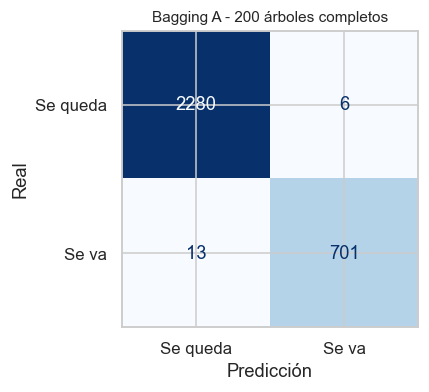

In [11]:
bagging_a = BaggingClassifier(
    estimator=DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    n_estimators=200,
    max_samples=1.0,        # cada árbol ve tantas filas como el original (con reemplazo)
    max_features=1.0,       # y todos los atributos
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE)

t0 = time.time()
bagging_a.fit(X_train, y_train)
t_bag_a = time.time() - t0

BAG_A = "Bagging A - 200 árboles completos"
print(f"Árboles del ensemble                 : {len(bagging_a.estimators_)}")
print(f"Profundidad media de los árboles base: {np.mean([e.get_depth() for e in bagging_a.estimators_]):.1f}")
print(f"Hojas medias por árbol               : {np.mean([e.get_n_leaves() for e in bagging_a.estimators_]):.0f}")
print(f"Accuracy out-of-bag (OOB)            : {bagging_a.oob_score_:.4f}")
print(f"Tiempo de entrenamiento              : {t_bag_a:.2f} s")
print()
evaluar(BAG_A, bagging_a, t_bag_a, familia="Bagging")
matriz_confusion(bagging_a, BAG_A)
plt.show()

## 1.2 `BaggingClassifier` - configuración B: árboles podados y submuestreo de atributos

Cambiamos **tres** hiperparámetros respecto a la configuración A, para ver el efecto de cada palanca:

* `estimator`: árbol **podado** (`max_depth=12`, `min_samples_leaf=5`) en lugar de completo → menos varianza por
  árbol, pero algo más de sesgo.
* `max_samples=0.6`: cada árbol ve solo el 60% de las filas → más diversidad entre árboles.
* `max_features=0.6`: cada árbol ve solo el 60% de los atributos (*random subspace*) → los descorrelaciona.

Subimos también a `n_estimators=300`, porque cuanta más diversidad se introduce más árboles hacen falta para que el
promedio se estabilice.

Filas vistas por árbol    : 7199 de 11999
Atributos vistos por árbol: 10 de 17
Accuracy out-of-bag (OOB) : 0.9808
Tiempo de entrenamiento   : 1.84 s



===== Bagging B - 300 árboles podados, 60% filas y columnas =====
              precision    recall  f1-score   support

Se queda (0)     0.9798    0.9948    0.9872      2286
   Se va (1)     0.9823    0.9342    0.9576       714

    accuracy                         0.9803      3000
   macro avg     0.9810    0.9645    0.9724      3000
weighted avg     0.9804    0.9803    0.9802      3000

ROC-AUC: 0.9931   PR-AUC: 0.9834   F1 train: 0.9723   F1 test: 0.9576   (gap: +0.0147)   FN: 47   FP: 12


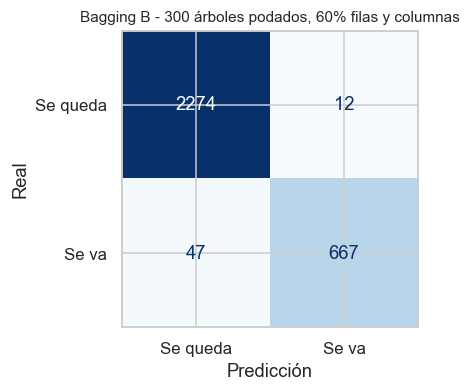

In [12]:
bagging_b = BaggingClassifier(
    estimator=DecisionTreeClassifier(class_weight="balanced", max_depth=12,
                                     min_samples_leaf=5, random_state=RANDOM_STATE),
    n_estimators=300,
    max_samples=0.6,
    max_features=0.6,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE)

t0 = time.time()
bagging_b.fit(X_train, y_train)
t_bag_b = time.time() - t0

BAG_B = "Bagging B - 300 árboles podados, 60% filas y columnas"
print(f"Filas vistas por árbol    : {int(0.6 * len(X_train))} de {len(X_train)}")
print(f"Atributos vistos por árbol: {bagging_b.estimators_features_[0].shape[0]} de {len(FEATURES)}")
print(f"Accuracy out-of-bag (OOB) : {bagging_b.oob_score_:.4f}")
print(f"Tiempo de entrenamiento   : {t_bag_b:.2f} s")
print()
evaluar(BAG_B, bagging_b, t_bag_b, familia="Bagging")
matriz_confusion(bagging_b, BAG_B)
plt.show()

## 1.3 `RandomForestClassifier` - configuración A: el bosque clásico

`RandomForestClassifier` es bagging con una vuelta de tuerca: además del *bootstrap* de filas, **en cada nodo** solo
se considera un subconjunto aleatorio de atributos para buscar el mejor corte. Con `max_features='sqrt'` cada nodo
mira solo ⌊√17⌋ = 4 de los 17 atributos.

Esto es lo que impide que todos los árboles empiecen partiendo por `satisfaction_level` -el atributo dominante que
identificamos en el sprint 2- y acaben pareciéndose demasiado entre sí. La clave del bagging es que promediar
reduce la varianza **solo si los modelos promediados están poco correlacionados**.

Atributos candidatos por nodo   : 4 de 17
Profundidad media de los árboles: 23.3
Hojas medias por árbol          : 477
Accuracy out-of-bag (OOB)       : 0.9900
Tiempo de entrenamiento         : 2.31 s



===== Random Forest A - 300 árboles, max_features='sqrt' =====
              precision    recall  f1-score   support

Se queda (0)     0.9939    0.9974    0.9956      2286
   Se va (1)     0.9915    0.9804    0.9859       714

    accuracy                         0.9933      3000
   macro avg     0.9927    0.9889    0.9908      3000
weighted avg     0.9933    0.9933    0.9933      3000

ROC-AUC: 0.9954   PR-AUC: 0.9901   F1 train: 0.9998   F1 test: 0.9859   (gap: +0.0139)   FN: 14   FP: 6


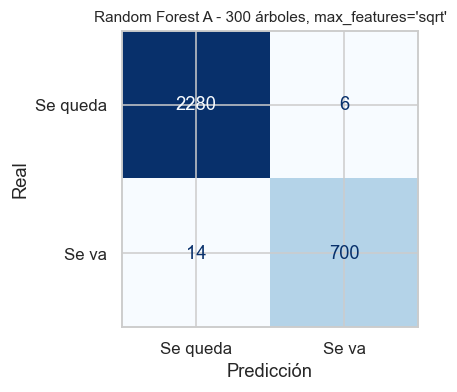

In [13]:
rf_a = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",      # ~4 atributos candidatos por nodo
    class_weight="balanced",
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE)

t0 = time.time()
rf_a.fit(X_train, y_train)
t_rf_a = time.time() - t0

RF_A = "Random Forest A - 300 árboles, max_features='sqrt'"
print(f"Atributos candidatos por nodo   : {int(np.sqrt(len(FEATURES)))} de {len(FEATURES)}")
print(f"Profundidad media de los árboles: {np.mean([e.get_depth() for e in rf_a.estimators_]):.1f}")
print(f"Hojas medias por árbol          : {np.mean([e.get_n_leaves() for e in rf_a.estimators_]):.0f}")
print(f"Accuracy out-of-bag (OOB)       : {rf_a.oob_score_:.4f}")
print(f"Tiempo de entrenamiento         : {t_rf_a:.2f} s")
print()
evaluar(RF_A, rf_a, t_rf_a, familia="Bagging")
matriz_confusion(rf_a, RF_A)
plt.show()

## 1.4 `RandomForestClassifier` - configuración B: sin aleatoriedad de atributos y con poda

La segunda configuración va deliberadamente en dirección contraria, para **aislar el efecto de la aleatoriedad de
atributos**:

* `max_features=None`: **todos** los atributos son candidatos en cada nodo. El bosque deja de estar descorrelacionado
  por atributos y se convierte, de hecho, en un bagging puro.
* `max_depth=12`, `min_samples_leaf=5`: árboles podados, como el árbol de referencia del sprint 2.
* `class_weight="balanced_subsample"`: los pesos de clase se recalculan **dentro de cada muestra bootstrap** en
  lugar de una sola vez sobre todo el conjunto, que es lo correcto cuando cada árbol ve una muestra distinta.

Si esta configuración empeora respecto a la A habremos demostrado empíricamente que la aleatoriedad de atributos es
lo que aporta el valor diferencial del Random Forest frente al bagging simple.

Profundidad media de los árboles: 12.0
Hojas medias por árbol          : 142
Accuracy out-of-bag (OOB)       : 0.9811
Tiempo de entrenamiento         : 2.68 s



===== Random Forest B - 300 árboles podados, max_features=None =====
              precision    recall  f1-score   support

Se queda (0)     0.9857    0.9943    0.9900      2286
   Se va (1)     0.9813    0.9538    0.9673       714

    accuracy                         0.9847      3000
   macro avg     0.9835    0.9740    0.9787      3000
weighted avg     0.9846    0.9847    0.9846      3000

ROC-AUC: 0.9936   PR-AUC: 0.9856   F1 train: 0.9757   F1 test: 0.9673   (gap: +0.0083)   FN: 33   FP: 13


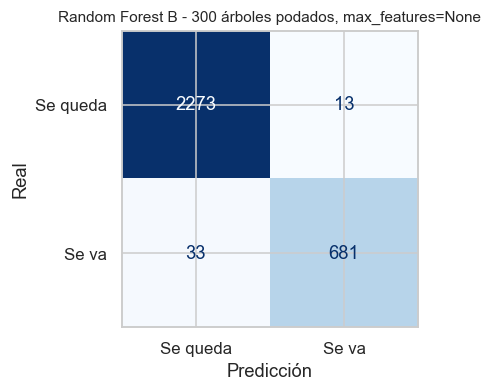

In [14]:
rf_b = RandomForestClassifier(
    n_estimators=300,
    max_features=None,        # todos los atributos candidatos en cada nodo
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE)

t0 = time.time()
rf_b.fit(X_train, y_train)
t_rf_b = time.time() - t0

RF_B = "Random Forest B - 300 árboles podados, max_features=None"
print(f"Profundidad media de los árboles: {np.mean([e.get_depth() for e in rf_b.estimators_]):.1f}")
print(f"Hojas medias por árbol          : {np.mean([e.get_n_leaves() for e in rf_b.estimators_]):.0f}")
print(f"Accuracy out-of-bag (OOB)       : {rf_b.oob_score_:.4f}")
print(f"Tiempo de entrenamiento         : {t_rf_b:.2f} s")
print()
evaluar(RF_B, rf_b, t_rf_b, familia="Bagging")
matriz_confusion(rf_b, RF_B)
plt.show()

## 1.5 ¿Cuántos árboles hacen falta? Curva del error *out-of-bag*

`n_estimators` merece un tratamiento aparte porque en bagging se comporta de una forma muy característica: **más
árboles nunca empeoran el modelo**. No hay riesgo de sobreajuste al añadirlos, solo coste computacional; lo único
que ocurre es que el promedio se estabiliza y la curva se aplana. (En la cuestión 2 veremos que en boosting esto
**no** es así.)

Dibujamos el error *out-of-bag* frente al número de árboles para las dos configuraciones de Random Forest, usando
`warm_start=True` para ir añadiendo árboles al mismo bosque en lugar de reentrenarlo desde cero.

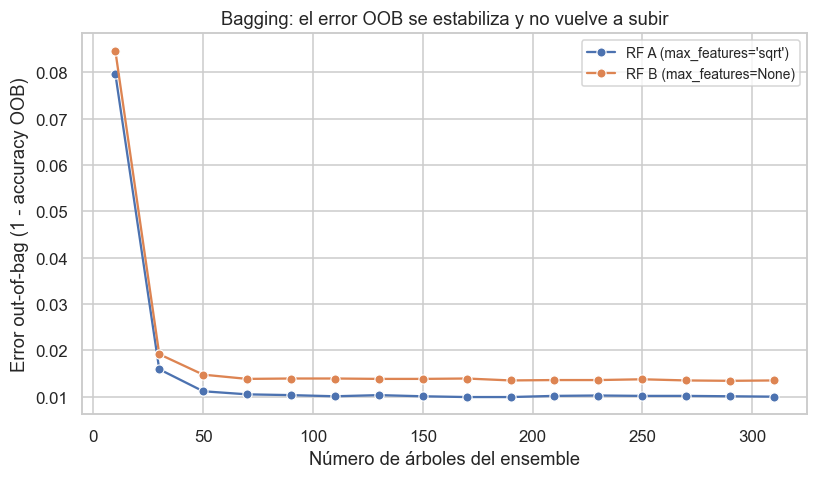

config,RF A (max_features='sqrt'),RF B (max_features=None)
n_estimators,,
10,0.07967,0.08467
30,0.01592,0.01917
50,0.01117,0.01475
70,0.01050,0.01383
90,0.01033,0.01392
110,0.01008,0.01392
130,0.01033,0.01383
150,0.01008,0.01383
170,0.00992,0.01392


In [15]:
rejilla_n = list(range(10, 311, 20))
curva_oob = []

for max_feat, etiqueta in [("sqrt", "RF A (max_features='sqrt')"),
                           (None,   "RF B (max_features=None)")]:
    bosque = RandomForestClassifier(warm_start=True, oob_score=True, max_features=max_feat,
                                    class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)
    for n in rejilla_n:
        bosque.set_params(n_estimators=n)
        bosque.fit(X_train, y_train)
        curva_oob.append({"n_estimators": n, "config": etiqueta,
                          "error_oob": 1 - bosque.oob_score_})

curva_oob = pd.DataFrame(curva_oob)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.lineplot(data=curva_oob, x="n_estimators", y="error_oob", hue="config", marker="o", ax=ax)
ax.set_xlabel("Número de árboles del ensemble")
ax.set_ylabel("Error out-of-bag (1 - accuracy OOB)")
ax.set_title("Bagging: el error OOB se estabiliza y no vuelve a subir")
ax.legend(fontsize=9)
plt.show()

curva_oob.pivot(index="n_estimators", columns="config", values="error_oob").round(5)

## 1.6 Resultados de la familia bagging

In [16]:
tabla_bagging = tabla_resultados(["Referencia", "Bagging"])
tabla_bagging.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc,f1_train,gap_f1,FN,FP,t_entren_s
modelo,,,,,,,,,,,
Bagging A - 200 árboles completos,0.9937,0.9915,0.9818,0.9866,0.9949,0.9887,1.0000,0.0134,13,6,10.6267
"Random Forest A - 300 árboles, max_features='sqrt'",0.9933,0.9915,0.9804,0.9859,0.9954,0.9901,0.9998,0.0139,14,6,2.3076
"Random Forest B - 300 árboles podados, max_features=None",0.9847,0.9813,0.9538,0.9673,0.9936,0.9856,0.9757,0.0083,33,13,2.6812
Árbol individual - sin poda (sprint 2),0.9840,0.9512,0.9832,0.9669,0.9837,0.9392,1.0000,0.0331,12,36,0.0427
"Bagging B - 300 árboles podados, 60% filas y columnas",0.9803,0.9823,0.9342,0.9576,0.9931,0.9834,0.9723,0.0147,47,12,1.8439
Árbol individual - max_depth=12 (sprint 2),0.9737,0.9308,0.9608,0.9456,0.9887,0.9775,0.9621,0.0165,28,51,0.0375


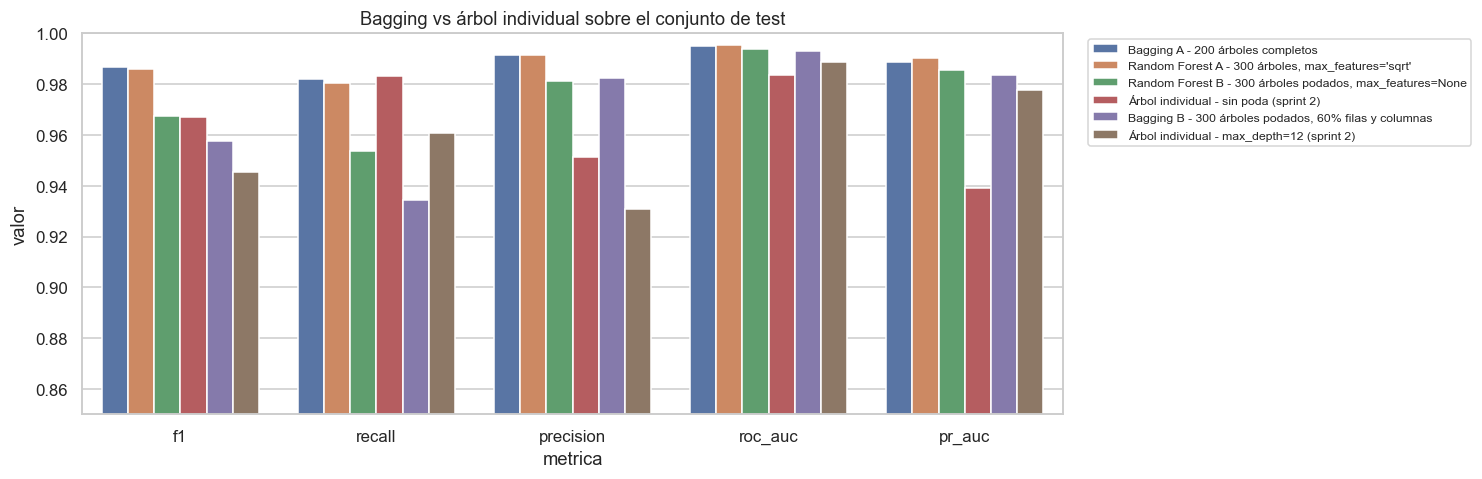

In [17]:
metricas = ["f1", "recall", "precision", "roc_auc", "pr_auc"]
comparativa = (tabla_bagging[metricas].reset_index()
               .melt(id_vars="modelo", var_name="metrica", value_name="valor"))

fig, ax = plt.subplots(figsize=(11.5, 4.5))
sns.barplot(data=comparativa, x="metrica", y="valor", hue="modelo", ax=ax)
ax.set_ylim(0.85, 1.0)
ax.set_title("Bagging vs árbol individual sobre el conjunto de test")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.show()

### Análisis de la cuestión 1

| Modelo | F1 | Recall | Precisión | ROC-AUC | PR-AUC | Gap F1 | FN | FP | OOB | Tiempo |
|---|---|---|---|---|---|---|---|---|---|---|
| Bagging A (200 completos) | **0.9866** | 0.9818 | **0.9915** | 0.9949 | 0.9887 | 0.0134 | 13 | **6** | 0.9888 | 8.2 s |
| Random Forest A (`sqrt`) | 0.9859 | 0.9804 | **0.9915** | **0.9954** | **0.9901** | 0.0139 | 14 | **6** | **0.9900** | **2.1 s** |
| Random Forest B (podado) | 0.9673 | 0.9538 | 0.9813 | 0.9936 | 0.9856 | **0.0083** | 33 | 13 | 0.9811 | 2.3 s |
| Bagging B (podado, 60/60) | 0.9576 | 0.9342 | 0.9823 | 0.9931 | 0.9834 | 0.0147 | 47 | 12 | 0.9808 | 1.7 s |
| *Árbol individual sin poda* | *0.9669* | *0.9832* | *0.9512* | *0.9837* | *0.9392* | *0.0331* | *12* | *36* | - | *0.03 s* |

**1. El bagging mejora al árbol, pero no por donde uno esperaría.** Bagging A sube el F1 de 0.9669 a 0.9866
(+2,0 puntos), y si se mira el detalle, **toda la ganancia está en la precisión**: pasa de 0.9512 a 0.9915, es
decir, los falsos positivos caen de 36 a 6. El recall se queda igual (0.9832 → 0.9818): el ensemble **no encuentra
más empleados que se van**, simplemente **deja de dar falsas alarmas**.

Esto es exactamente lo que predice la teoría. Los falsos positivos del árbol individual venían de hojas construidas
sobre un puñado de empleados concretos -decisiones idiosincrásicas, puro ruido de esa muestra de entrenamiento-.
Al promediar 200 árboles entrenados sobre remuestreos distintos, esas decisiones particulares se quedan en minoría
y desaparecen del voto. Es **reducción de varianza** en estado puro, y lo cuantificamos en la sección 5.2: la
varianza del árbol cae un 63% mientras el sesgo se queda **exactamente igual**.

**2. La mejora más grande no está en el F1, sino en el PR-AUC: 0.9392 → 0.9887 (+5,0 puntos).** Y la razón es la
misma que discutíamos en el sprint 2: un árbol sin podar tiene hojas puras, así que devuelve probabilidades que son
prácticamente 0 o 1 y no permiten **ordenar** a los empleados por riesgo. El ensemble devuelve la *proporción de
votos* de 200 árboles, que es una escala continua y graduada. Para el uso real -entregarle a RRHH una lista
priorizada de empleados en riesgo- esta diferencia importa más que el F1.

**3. Comparando las dos configuraciones de cada modelo, gana la A en los dos casos, y por bastante.** Bagging A
(0.9866) supera a Bagging B (0.9576) y Random Forest A (0.9859) a Random Forest B (0.9673). Las configuraciones B
comparten podar el árbol base (`max_depth=12`, `min_samples_leaf=5`), y ahí está la explicación:

> **El bagging quiere árboles con poco sesgo aunque tengan mucha varianza**, porque el promedio le quita la
> varianza pero **no le puede quitar el sesgo**. Podar el árbol base introduce un sesgo que ninguna cantidad de
> árboles va a eliminar después.

Es justo el consejo contrario al del sprint 2 -donde podar era lo razonable- y es la consecuencia práctica más útil
de este apartado: **al pasar de un árbol a un ensemble de bagging hay que dejar de podar**. Bagging B tiene, de
hecho, el peor recall de los cuatro (0.9342, 47 falsos negativos): el submuestreo al 60% de filas *y* columnas,
sumado a la poda, deja a cada árbol con demasiada poca información.

**4. La aleatoriedad de atributos del Random Forest no aporta poder predictivo aquí, pero sí velocidad.** La
comparación limpia es Bagging A (`max_features=1.0`, árboles completos) frente a Random Forest A
(`max_features='sqrt'`, árboles completos): 0.9866 frente a 0.9859, una diferencia de 0.0007 que es ruido. Con
solo 17 atributos, uno de ellos claramente dominante, descorrelacionar los árboles no encuentra señal adicional
que aprovechar.

Lo que sí consigue es **entrenar casi 4 veces más rápido** (2.1 s frente a 8.2 s), porque cada nodo solo evalúa 4
atributos candidatos en lugar de 17, y además obtiene el **mejor OOB** (0.9900) y los mejores ROC-AUC y PR-AUC del
grupo. A igualdad de acierto, ese es un argumento suficiente para preferirlo.

*(La configuración RF B no sirve para aislar el efecto de `max_features` porque cambia a la vez la aleatoriedad de
atributos y la poda; su peor resultado se explica sobre todo por lo segundo, como muestra el paralelismo con
Bagging B.)*

**5. El número de árboles importa poco a partir de ~70.** La curva OOB cae en picado de 0.0797 con 10 árboles a
0.0105 con 70, y a partir de ahí oscila en torno a 0.0100 sin volver a subir en ningún momento. Es la propiedad
característica del bagging: **`n_estimators` no es un hiperparámetro que haya que ajustar con cuidado**, basta con
poner "suficientes" y el único coste de pasarse es de cómputo. En la cuestión 2 veremos que con boosting esto no se
puede hacer.

**6. Y una advertencia: el `f1_train` de Bagging A sigue siendo 1.0000.** El ensemble memoriza el conjunto de
entrenamiento igual que el árbol individual; lo que ha mejorado es que generaliza mejor pese a ello (el `gap` baja
de 0.0331 a 0.0134). Con el 31% de duplicados que documentamos en la sección 0.3, este es precisamente el tipo de
modelo cuyas métricas absolutas hay que leer con más cautela.

# CUESTIÓN 2 - Ensembles de *Boosting* sobre árboles de decisión

La segunda familia que pide el enunciado. El cambio conceptual respecto al bagging es completo:

| | Bagging | Boosting |
|---|---|---|
| Entrenamiento | árboles **en paralelo**, independientes | árboles **en secuencia**, cada uno corrige al anterior |
| Modelo base | árbol **profundo** (sesgo bajo, varianza alta) | árbol **pequeño** (*weak learner*: sesgo alto, varianza baja) |
| Qué reduce | la **varianza** | el **sesgo** |
| `n_estimators` alto | inofensivo, solo cuesta tiempo | **puede sobreajustar** |
| Paralelizable | sí (`n_jobs=-1`) | no: cada árbol necesita el anterior |

Aplicamos los dos algoritmos de boosting vistos en clase, con dos configuraciones cada uno:

| Modelo | Cómo corrige | Configuración A | Configuración B |
|---|---|---|---|
| `AdaBoostClassifier` | **repondera las muestras**: las mal clasificadas pesan más en el árbol siguiente | 300 *stumps* (`max_depth=1`), `learning_rate=1.0` | 300 árboles `max_depth=5`, `learning_rate=0.5` |
| `GradientBoostingClassifier` | cada árbol ajusta el **gradiente del error** (los residuos) del ensemble acumulado | 200 árboles, `learning_rate=0.1`, `max_depth=3` | 500 árboles, `learning_rate=0.05`, `max_depth=5`, `subsample=0.8` |

## 2.1 `AdaBoostClassifier` - configuración A: *stumps* (`max_depth=1`)

El caso de libro de AdaBoost: el *weak learner* es un **tocón** (*stump*), un árbol de un solo corte que apenas
supera al azar. Cada iteración aumenta el peso de los empleados mal clasificados, de modo que el árbol siguiente se
concentra en ellos, y el voto final es una suma ponderada donde cada árbol pesa según su acierto.

Con `max_depth=1` el ensemble es puramente aditivo sobre variables sueltas: **no puede capturar interacciones**
entre atributos dentro de un mismo árbol. Es una limitación seria en este problema, donde en el sprint 2 vimos que
lo que explica la rotación es precisamente la *combinación* de satisfacción, antigüedad y evaluación.

El desbalanceo se compensa con la distribución inicial de pesos (`AdaBoostPonderado` de la sección 0.5) y **no**
con `class_weight` en el árbol base, por el motivo que comprobamos justo a continuación.

Árboles realmente entrenados: 300 de 300 solicitados
Tiempo de entrenamiento     : 2.19 s



===== AdaBoost A - 300 stumps (max_depth=1), lr=1.0 =====
              precision    recall  f1-score   support

Se queda (0)     0.9775    0.9300    0.9531      2286
   Se va (1)     0.8061    0.9314    0.8642       714

    accuracy                         0.9303      3000
   macro avg     0.8918    0.9307    0.9087      3000
weighted avg     0.9367    0.9303    0.9320      3000

ROC-AUC: 0.9757   PR-AUC: 0.9425   F1 train: 0.8792   F1 test: 0.8642   (gap: +0.0150)   FN: 49   FP: 160


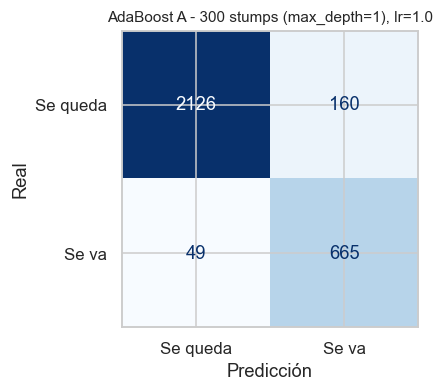

In [18]:
ada_a = AdaBoostPonderado(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    n_estimators=300,
    learning_rate=1.0,
    random_state=RANDOM_STATE)

t0 = time.time()
ada_a.fit(X_train, y_train)
t_ada_a = time.time() - t0

ADA_A = "AdaBoost A - 300 stumps (max_depth=1), lr=1.0"
print(f"Árboles realmente entrenados: {len(ada_a)} de {ada_a.n_estimators} solicitados")
print(f"Tiempo de entrenamiento     : {t_ada_a:.2f} s")
print()
evaluar(ADA_A, ada_a, t_ada_a, familia="Boosting")
matriz_confusion(ada_a, ADA_A)
plt.show()

### Comprobación: por qué `class_weight` rompe AdaBoost

Anunciábamos en la sección 0.5 que poner `class_weight="balanced"` en el árbol base -que es lo que hicimos en todos
los modelos del sprint 2, y lo que uno haría por inercia- **interrumpe el boosting**. Merece la pena verlo, porque
es un error silencioso: `scikit-learn` no avisa, simplemente devuelve un ensemble con muy pocos árboles.

El motivo es que AdaBoost y el árbol estarían optimizando con pesos distintos. AdaBoost mantiene su propia
distribución de pesos, mide con ella el error del árbol recién entrenado y **aborta si ese error supera 0.5**
(el nivel del azar en un problema binario). Si el árbol, por su cuenta, ha optimizado con otros pesos, es fácil
que su error medido por AdaBoost cruce ese umbral y el algoritmo se detenga.

In [19]:
diagnostico = []
for etiqueta, base, pesos_iniciales in [
    ("class_weight='balanced' en el árbol base",
     DecisionTreeClassifier(max_depth=1, class_weight="balanced", random_state=RANDOM_STATE), None),
    ("árbol base sin class_weight, sin ponderar",
     DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE), None),
    ("árbol base sin class_weight + sample_weight balanceado (el que usamos)",
     DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE), pesos),
]:
    prueba = AdaBoostClassifier(estimator=base, n_estimators=300, learning_rate=1.0,
                                random_state=RANDOM_STATE)
    prueba.fit(X_train, y_train, sample_weight=pesos_iniciales)
    diagnostico.append({"configuración": etiqueta,
                        "árboles entrenados": len(prueba),
                        "f1_test": f1_score(y_test, prueba.predict(X_test))})

pd.DataFrame(diagnostico).set_index("configuración").round(4)

,árboles entrenados,f1_test
configuración,,
class_weight='balanced' en el árbol base,3,0.6757
"árbol base sin class_weight, sin ponderar",300,0.9034
árbol base sin class_weight + sample_weight balanceado (el que usamos),300,0.8642


## 2.2 `AdaBoostClassifier` - configuración B: árboles de profundidad 5 y tasa de aprendizaje menor

Cambiamos las dos palancas fundamentales de AdaBoost a la vez:

* `estimator` con `max_depth=5`: el modelo base deja de ser un tocón y **sí puede representar interacciones** entre
  variables (hasta 5 condiciones encadenadas). Es la configuración que usa el material de clase
  (`AdaBoostClassifier(DecisionTreeClassifier(max_depth=5), ...)`).
* `learning_rate=0.5`: cada árbol contribuye la mitad al voto final. Una tasa más baja obliga a dar más pasos pero
  hace el descenso más fino y **reduce el riesgo de sobreajuste**; es el clásico compromiso entre `learning_rate` y
  `n_estimators`.

Árboles realmente entrenados: 300 de 300 solicitados
Tiempo de entrenamiento     : 6.28 s



===== AdaBoost B - 300 árboles max_depth=5, lr=0.5 =====
              precision    recall  f1-score   support

Se queda (0)     0.9872    0.9821    0.9846      2286
   Se va (1)     0.9435    0.9594    0.9514       714

    accuracy                         0.9767      3000
   macro avg     0.9654    0.9707    0.9680      3000
weighted avg     0.9768    0.9767    0.9767      3000

ROC-AUC: 0.9941   PR-AUC: 0.9867   F1 train: 0.9719   F1 test: 0.9514   (gap: +0.0205)   FN: 29   FP: 41


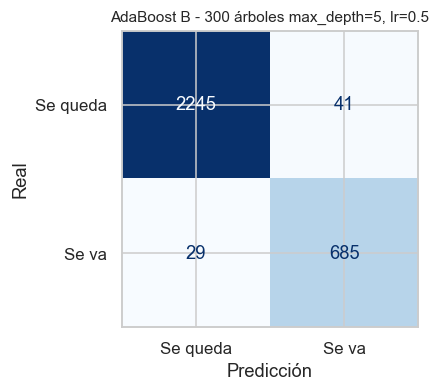

In [20]:
ada_b = AdaBoostPonderado(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    n_estimators=300,
    learning_rate=0.5,
    random_state=RANDOM_STATE)

t0 = time.time()
ada_b.fit(X_train, y_train)
t_ada_b = time.time() - t0

ADA_B = "AdaBoost B - 300 árboles max_depth=5, lr=0.5"
print(f"Árboles realmente entrenados: {len(ada_b)} de {ada_b.n_estimators} solicitados")
print(f"Tiempo de entrenamiento     : {t_ada_b:.2f} s")
print()
evaluar(ADA_B, ada_b, t_ada_b, familia="Boosting")
matriz_confusion(ada_b, ADA_B)
plt.show()

### Evolución del error al añadir árboles

`staged_predict()` devuelve la predicción del ensemble después de cada iteración, así que permite dibujar cómo
evoluciona el error según se van encadenando árboles -exactamente el gráfico del notebook de clase de AdaBoost-.
Aquí lo hacemos para las dos configuraciones y **midiendo también el error en entrenamiento**, que es lo que
permite ver el sobreajuste.

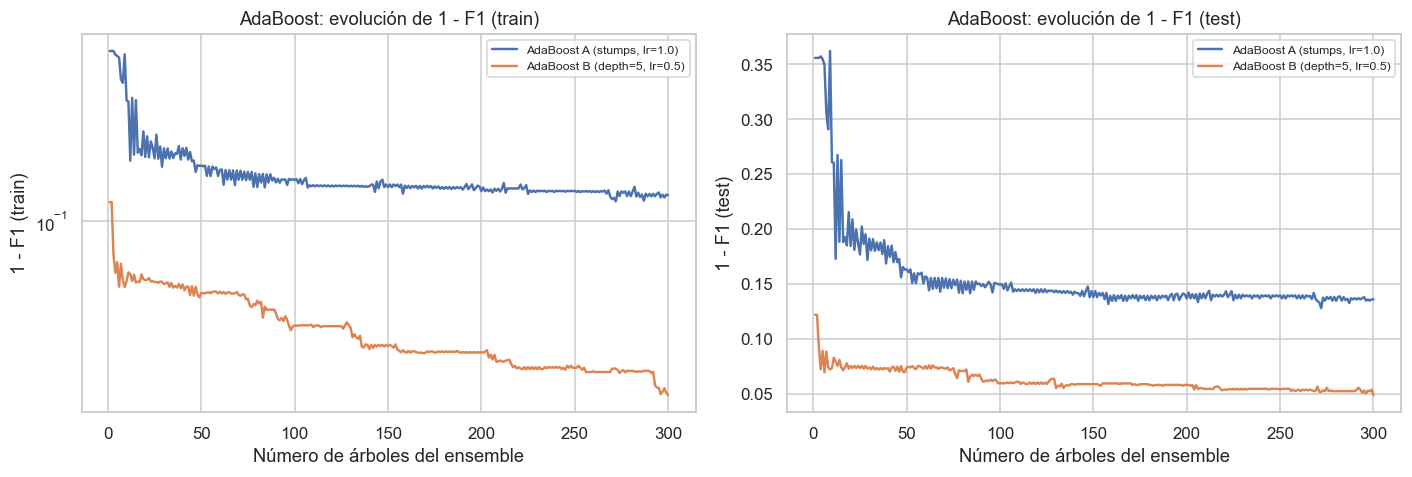

Número de árboles que minimiza el error en test:
                      config  n_arboles  1 - F1 (test)
 AdaBoost A (stumps, lr=1.0)        272       0.127869
AdaBoost B (depth=5, lr=0.5)        300       0.048611


In [21]:
def curva_boosting(modelo, etiqueta):
    """Error (1 - F1) en train y test tras cada iteración del boosting."""
    filas = []
    for i, (p_tr, p_te) in enumerate(zip(modelo.staged_predict(X_train),
                                         modelo.staged_predict(X_test)), start=1):
        filas.append({"n_arboles": i, "config": etiqueta,
                      "1 - F1 (train)": 1 - f1_score(y_train, p_tr),
                      "1 - F1 (test)":  1 - f1_score(y_test,  p_te)})
    return pd.DataFrame(filas)


curvas_ada = pd.concat([curva_boosting(ada_a, "AdaBoost A (stumps, lr=1.0)"),
                        curva_boosting(ada_b, "AdaBoost B (depth=5, lr=0.5)")],
                       ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for ax, conjunto in zip(axes, ["1 - F1 (train)", "1 - F1 (test)"]):
    sns.lineplot(data=curvas_ada, x="n_arboles", y=conjunto, hue="config", ax=ax, lw=1.6)
    ax.set_xlabel("Número de árboles del ensemble")
    ax.set_ylabel(conjunto)
    ax.set_title(f"AdaBoost: evolución de {conjunto}")
    ax.legend(fontsize=8)
axes[0].set_yscale("log")
plt.tight_layout()
plt.show()

optimos = (curvas_ada.loc[curvas_ada.groupby("config")["1 - F1 (test)"].idxmin()]
           [["config", "n_arboles", "1 - F1 (test)"]])
print("Número de árboles que minimiza el error en test:")
print(optimos.to_string(index=False))

## 2.3 `GradientBoostingClassifier` - configuración A: configuración estándar

El *gradient boosting* generaliza la idea de AdaBoost: en lugar de reponderar las muestras, cada árbol nuevo se
entrena para predecir el **gradiente negativo de la función de pérdida** (con pérdida logarítmica, los residuos
del ensemble acumulado). Los tres hiperparámetros que lo gobiernan son `n_estimators`, `learning_rate` y
`max_depth`, y están fuertemente acoplados entre sí.

Igual que AdaBoost, `GradientBoostingClassifier` **no admite `class_weight`**: usamos la subclase `GBPonderado`
definida en la sección 0.5, que aplica los pesos balanceados por muestra.

A diferencia de AdaBoost, aquí el problema del *early stopping* no aparece: el gradient boosting no comprueba
ningún umbral de error sobre sus árboles base, simplemente sigue ajustando residuos hasta agotar `n_estimators`.

Árboles del ensemble   : 200
Tiempo de entrenamiento: 2.61 s

===== Gradient Boosting A - 200 árboles, lr=0.1, depth=3 =====
              precision    recall  f1-score   support

Se queda (0)     0.9828    0.9773    0.9800      2286
   Se va (1)     0.9285    0.9454    0.9368       714

    accuracy                         0.9697      3000
   macro avg     0.9557    0.9613    0.9584      3000
weighted avg     0.9699    0.9697    0.9698      3000

ROC-AUC: 0.9899   PR-AUC: 0.9790   F1 train: 0.9497   F1 test: 0.9368   (gap: +0.0128)   FN: 39   FP: 52


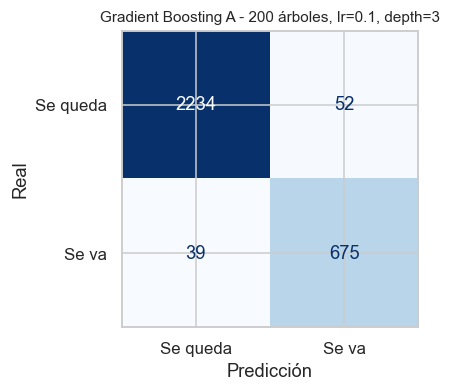

In [22]:
gb_a = GBPonderado(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE)

t0 = time.time()
gb_a.fit(X_train, y_train)
t_gb_a = time.time() - t0

GB_A = "Gradient Boosting A - 200 árboles, lr=0.1, depth=3"
print(f"Árboles del ensemble   : {gb_a.n_estimators_}")
print(f"Tiempo de entrenamiento: {t_gb_a:.2f} s")
print()
evaluar(GB_A, gb_a, t_gb_a, familia="Boosting")
matriz_confusion(gb_a, GB_A)
plt.show()

## 2.4 `GradientBoostingClassifier` - configuración B: más árboles, paso más corto y submuestreo

La segunda configuración explora el compromiso clásico **"muchos pasos pequeños"** frente a "pocos pasos grandes":

* `learning_rate=0.05` (la mitad) compensado con `n_estimators=500` (2,5 veces más árboles).
* `max_depth=5`: árboles base capaces de capturar interacciones de hasta cinco variables.
* `subsample=0.8`: cada árbol se ajusta sobre un 80% aleatorio de las filas. Esto convierte el algoritmo en
  *stochastic gradient boosting* e introduce en el boosting una pizca de la aleatoriedad del bagging, lo que suele
  reducir la varianza y actuar como regularizador.

Árboles del ensemble   : 500
Tiempo de entrenamiento: 9.57 s

===== Gradient Boosting B - 500 árboles, lr=0.05, depth=5, subsample=0.8 =====
              precision    recall  f1-score   support

Se queda (0)     0.9947    0.9878    0.9912      2286
   Se va (1)     0.9616    0.9832    0.9723       714

    accuracy                         0.9867      3000
   macro avg     0.9782    0.9855    0.9818      3000
weighted avg     0.9868    0.9867    0.9867      3000

ROC-AUC: 0.9960   PR-AUC: 0.9908   F1 train: 0.9977   F1 test: 0.9723   (gap: +0.0254)   FN: 12   FP: 28


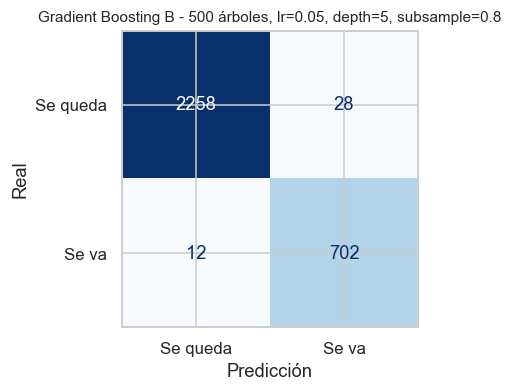

In [23]:
gb_b = GBPonderado(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=RANDOM_STATE)

t0 = time.time()
gb_b.fit(X_train, y_train)
t_gb_b = time.time() - t0

GB_B = "Gradient Boosting B - 500 árboles, lr=0.05, depth=5, subsample=0.8"
print(f"Árboles del ensemble   : {gb_b.n_estimators_}")
print(f"Tiempo de entrenamiento: {t_gb_b:.2f} s")
print()
evaluar(GB_B, gb_b, t_gb_b, familia="Boosting")
matriz_confusion(gb_b, GB_B)
plt.show()

### Evolución del error del gradient boosting

El mismo diagnóstico que hicimos con AdaBoost. Es el gráfico que revela si nos hemos pasado de árboles: si la curva
de test toca un mínimo y luego remonta mientras la de train sigue bajando, el ensemble está sobreajustando y habría
que parar antes (*early stopping*).

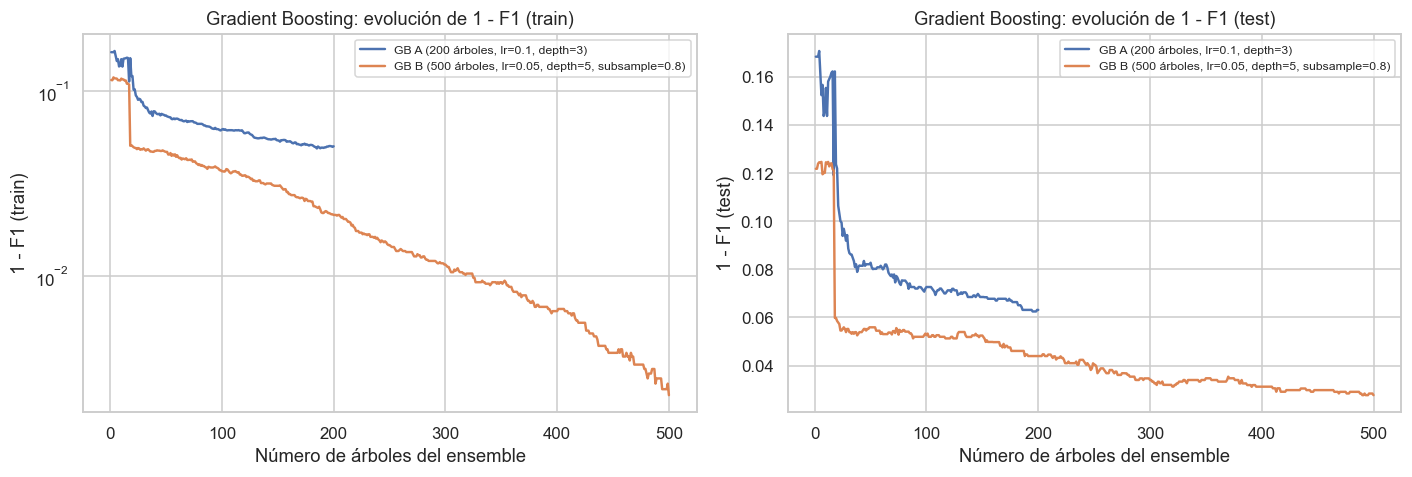

Número de árboles que minimiza el error en test:
                                             config  n_arboles  1 - F1 (test)
                GB A (200 árboles, lr=0.1, depth=3)        195       0.062500
GB B (500 árboles, lr=0.05, depth=5, subsample=0.8)        490       0.027701


In [24]:
curvas_gb = pd.concat([curva_boosting(gb_a, "GB A (200 árboles, lr=0.1, depth=3)"),
                       curva_boosting(gb_b, "GB B (500 árboles, lr=0.05, depth=5, subsample=0.8)")],
                      ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, conjunto in zip(axes, ["1 - F1 (train)", "1 - F1 (test)"]):
    sns.lineplot(data=curvas_gb, x="n_arboles", y=conjunto, hue="config", ax=ax, lw=1.6)
    ax.set_xlabel("Número de árboles del ensemble")
    ax.set_ylabel(conjunto)
    ax.set_title(f"Gradient Boosting: evolución de {conjunto}")
    ax.legend(fontsize=8)
axes[0].set_yscale("log")
plt.tight_layout()
plt.show()

optimos_gb = (curvas_gb.loc[curvas_gb.groupby("config")["1 - F1 (test)"].idxmin()]
              [["config", "n_arboles", "1 - F1 (test)"]])
print("Número de árboles que minimiza el error en test:")
print(optimos_gb.to_string(index=False))

## 2.5 Resultados de la familia boosting

In [25]:
tabla_boosting = tabla_resultados(["Referencia", "Boosting"])
tabla_boosting.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc,f1_train,gap_f1,FN,FP,t_entren_s
modelo,,,,,,,,,,,
"Gradient Boosting B - 500 árboles, lr=0.05, depth=5, subsample=0.8",0.9867,0.9616,0.9832,0.9723,0.9960,0.9908,0.9977,0.0254,12,28,9.5656
Árbol individual - sin poda (sprint 2),0.9840,0.9512,0.9832,0.9669,0.9837,0.9392,1.0000,0.0331,12,36,0.0427
"AdaBoost B - 300 árboles max_depth=5, lr=0.5",0.9767,0.9435,0.9594,0.9514,0.9941,0.9867,0.9719,0.0205,29,41,6.2807
Árbol individual - max_depth=12 (sprint 2),0.9737,0.9308,0.9608,0.9456,0.9887,0.9775,0.9621,0.0165,28,51,0.0375
"Gradient Boosting A - 200 árboles, lr=0.1, depth=3",0.9697,0.9285,0.9454,0.9368,0.9899,0.9790,0.9497,0.0128,39,52,2.6118
"AdaBoost A - 300 stumps (max_depth=1), lr=1.0",0.9303,0.8061,0.9314,0.8642,0.9757,0.9425,0.8792,0.0150,49,160,2.1948


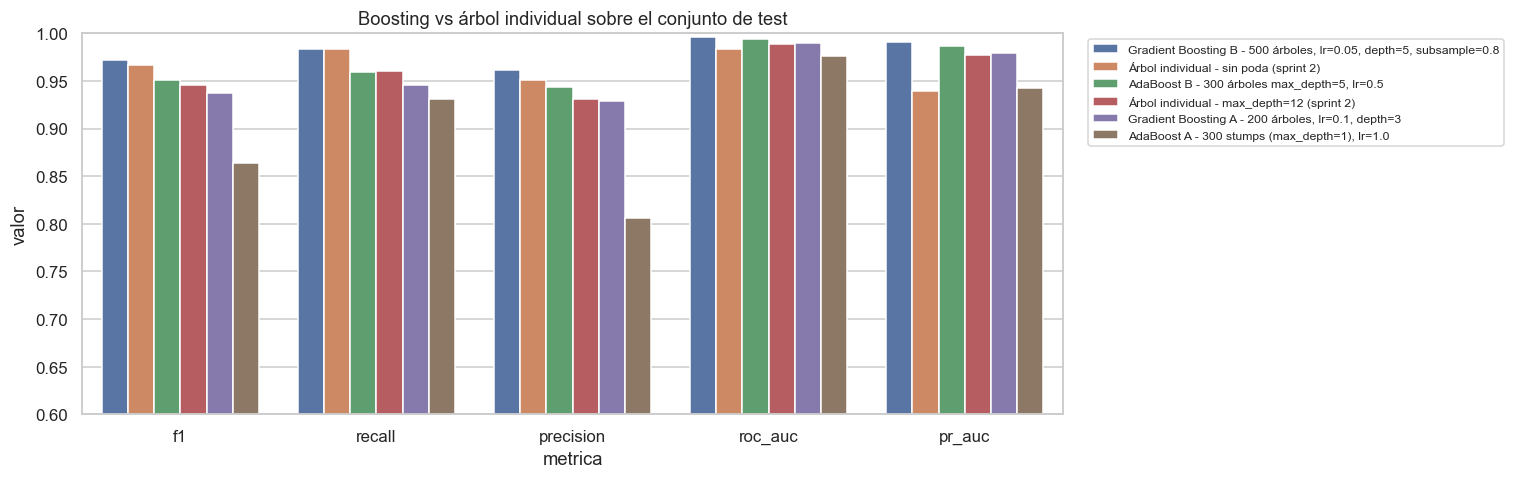

In [26]:
comparativa_b = (tabla_boosting[metricas].reset_index()
                 .melt(id_vars="modelo", var_name="metrica", value_name="valor"))

fig, ax = plt.subplots(figsize=(11.5, 4.5))
sns.barplot(data=comparativa_b, x="metrica", y="valor", hue="modelo", ax=ax)
ax.set_ylim(0.6, 1.0)
ax.set_title("Boosting vs árbol individual sobre el conjunto de test")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.show()

### Análisis de la cuestión 2

| Modelo | F1 | Recall | Precisión | ROC-AUC | PR-AUC | Gap F1 | FN | FP | Tiempo |
|---|---|---|---|---|---|---|---|---|---|
| Gradient Boosting B (500, lr=0.05, d=5, sub=0.8) | **0.9723** | **0.9832** | **0.9616** | **0.9960** | **0.9908** | 0.0254 | **12** | **28** | 9.3 s |
| AdaBoost B (300, d=5, lr=0.5) | 0.9514 | 0.9594 | 0.9435 | 0.9941 | 0.9867 | 0.0205 | 29 | 41 | 6.5 s |
| Gradient Boosting A (200, lr=0.1, d=3) | 0.9368 | 0.9454 | 0.9285 | 0.9899 | 0.9790 | **0.0128** | 39 | 52 | 2.4 s |
| AdaBoost A (300 *stumps*, lr=1.0) | 0.8642 | 0.9314 | 0.8061 | 0.9757 | 0.9425 | 0.0150 | 49 | 160 | **2.0 s** |
| *Árbol individual sin poda* | *0.9669* | *0.9832* | *0.9512* | *0.9837* | *0.9392* | *0.0331* | *12* | *36* | *0.03 s* |

**1. La profundidad del modelo base es, con diferencia, el hiperparámetro decisivo.** Pasar de *stumps* a árboles
de profundidad 5 sube el F1 de AdaBoost de 0.8642 a 0.9514 (+8,7 puntos) y reduce los falsos positivos de 160 a 41.
En Gradient Boosting el salto de `max_depth=3` a `max_depth=5` va acompañado del mismo efecto (0.9368 → 0.9723).

El motivo conecta directamente con lo que aprendimos en el sprint 2: **la rotación se explica por interacciones**,
no por variables sueltas. Los dos perfiles de fuga que identificamos allí -el empleado quemado (satisfacción baja
**y** 3-4 años de antigüedad) y el empleado valioso sin recorrido (satisfacción alta **y** veterano **y** con
evaluación > 0.8)- son reglas de tres condiciones simultáneas. Un *stump* de un solo corte **no puede representar
una conjunción**: por muchos que sumemos, el modelo resultante es aditivo sobre variables individuales y se queda
sin poder describir un perfil. Los árboles de profundidad 5 sí pueden, y ahí está la diferencia de 8,7 puntos.

Esto matiza el discurso habitual de que "el boosting funciona con aprendices débiles": es cierto que el
*weak learner* debe ser débil, pero **debe ser suficientemente expresivo para la estructura del problema**. En un
problema de interacciones, un tocón no es débil, es ciego.

**2. `class_weight` en el árbol base rompe AdaBoost, y lo hace en silencio.** La tabla de diagnóstico de la
sección 2.1 es contundente: con `class_weight="balanced"` en el árbol, AdaBoost entrena **3 árboles de los 300
solicitados** y se queda en F1 = 0.6757; quitándolo y compensando el desbalanceo con `sample_weight`, entrena los
300 y llega a 0.8642. El ensemble "funcionaba" sin lanzar ningún error, simplemente era 100 veces más pequeño de lo
que creíamos. Es el tipo de fallo que solo se detecta si uno comprueba `len(modelo)` después de entrenar.

*(Detalle secundario: sin ponderar nada en absoluto, los mismos 300 tocones alcanzan F1 = 0.9034, por encima del
0.8642 de la versión ponderada. No es una contradicción: la ponderación desplaza el modelo hacia el recall
-0.9314 frente al recall sin ponderar- a costa de la precisión. Mantenemos la versión ponderada por coherencia con
el criterio de todo el proyecto, donde el falso negativo es el error caro.)*

**3. Ninguna de las curvas de boosting llega a remontar: no hemos llegado a sobreajustar.** El mínimo del error en
test se alcanza en el árbol 272 de 300 para AdaBoost A, en el 300 de 300 para AdaBoost B, en el 195 de 200 para
Gradient Boosting A y en el 490 de 500 para Gradient Boosting B. Es decir, **los cuatro modelos seguían mejorando
cuando se les acabó el presupuesto**: con más árboles habrían dado algo más de sí.

Conviene no sacar de aquí la conclusión equivocada. Que aquí no aparezca sobreajuste **no significa que el boosting
no sobreajuste**; significa que el problema tiene mucha señal, poco ruido y 12.000 observaciones. La forma correcta
de fijar `n_estimators` en boosting sigue siendo mirar esta curva -o usar `n_iter_no_change` para un *early
stopping* automático-, y no ponerle un número a ojo como se puede hacer en bagging.

**4. Gradient Boosting B es el mejor ordenador de riesgo de todo el notebook**, con el ROC-AUC (0.9960) y el PR-AUC
(0.9908) más altos de los diez modelos, y **empata con el árbol individual en el mínimo de falsos negativos: 12**.
Su F1 (0.9723) queda por debajo del bagging porque paga 28 falsos positivos frente a 6, pero si el objetivo del
cliente fuese *no dejar escapar a nadie*, este sería el modelo.

Las tres palancas que lo separan de la configuración A tiran en la misma dirección: `learning_rate` bajo (0.05) con
muchos árboles (500) hace un descenso más fino sobre la función de pérdida, `max_depth=5` da capacidad para las
interacciones, y `subsample=0.8` -el *stochastic gradient boosting*- inyecta en el boosting la diversidad del
bagging, que actúa como regularizador. El precio es el `gap` más alto de la familia (0.0254).

**5. El coste es el gran inconveniente del boosting.** Gradient Boosting B tarda 9,3 s frente a los 2,1 s del
Random Forest, y no porque haga más trabajo, sino porque **es secuencial**: cada árbol necesita los residuos del
anterior, así que no admite `n_jobs=-1`. El bagging reparte sus 300 árboles entre todos los núcleos disponibles.
En un escenario de reentrenamiento frecuente, esa diferencia estructural pesa.

# CUESTIÓN 3 - Comparación y discusión: ¿cuál es el mejor ensemble?

El enunciado pide **comparar y discutir los resultados identificando el mejor ensemble en cuanto a poder
predictivo**. Ponemos los ocho ensembles y los dos árboles de referencia en la misma tabla y los juzgamos con el
mismo criterio del sprint 2: **F1 de la clase positiva** como métrica de decisión, con recall, precisión, ROC-AUC y
PR-AUC como apoyo, y la *accuracy* como dato secundario por el desbalanceo.

Añadimos además tres análisis que una tabla de métricas sobre una única partición de test no puede dar por sí sola:

1. **Curvas ROC y Precisión-Recall** de todos los modelos, para comparar la calidad del *ranking* de riesgo y no
   solo la decisión con umbral 0.5.
2. **Validación cruzada** sobre el conjunto de entrenamiento, para saber si las diferencias observadas son reales o
   ruido de muestreo.
3. **Coste de entrenamiento**, porque a igualdad de resultados el modelo más barato es preferible.

In [27]:
tabla = tabla_resultados()
tabla.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc,f1_train,gap_f1,FN,FP,t_entren_s
modelo,,,,,,,,,,,
Bagging A - 200 árboles completos,0.9937,0.9915,0.9818,0.9866,0.9949,0.9887,1.0000,0.0134,13,6,10.6267
"Random Forest A - 300 árboles, max_features='sqrt'",0.9933,0.9915,0.9804,0.9859,0.9954,0.9901,0.9998,0.0139,14,6,2.3076
"Gradient Boosting B - 500 árboles, lr=0.05, depth=5, subsample=0.8",0.9867,0.9616,0.9832,0.9723,0.9960,0.9908,0.9977,0.0254,12,28,9.5656
"Random Forest B - 300 árboles podados, max_features=None",0.9847,0.9813,0.9538,0.9673,0.9936,0.9856,0.9757,0.0083,33,13,2.6812
Árbol individual - sin poda (sprint 2),0.9840,0.9512,0.9832,0.9669,0.9837,0.9392,1.0000,0.0331,12,36,0.0427
"Bagging B - 300 árboles podados, 60% filas y columnas",0.9803,0.9823,0.9342,0.9576,0.9931,0.9834,0.9723,0.0147,47,12,1.8439
"AdaBoost B - 300 árboles max_depth=5, lr=0.5",0.9767,0.9435,0.9594,0.9514,0.9941,0.9867,0.9719,0.0205,29,41,6.2807
Árbol individual - max_depth=12 (sprint 2),0.9737,0.9308,0.9608,0.9456,0.9887,0.9775,0.9621,0.0165,28,51,0.0375
"Gradient Boosting A - 200 árboles, lr=0.1, depth=3",0.9697,0.9285,0.9454,0.9368,0.9899,0.9790,0.9497,0.0128,39,52,2.6118


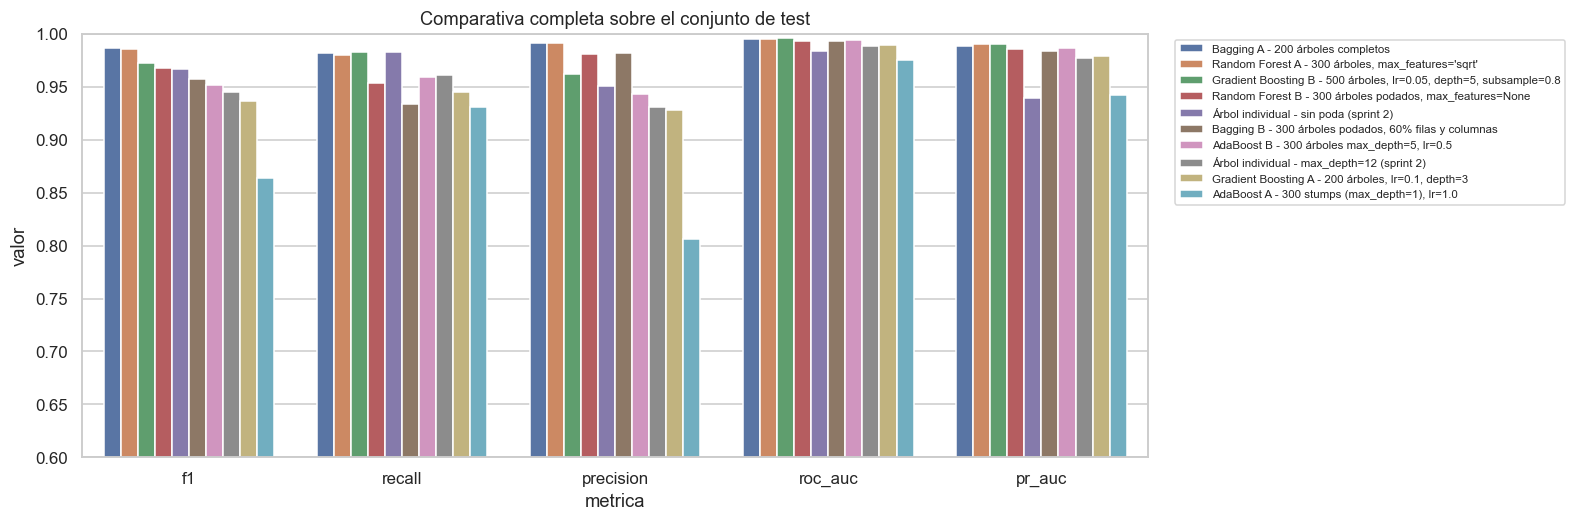

In [28]:
fig, ax = plt.subplots(figsize=(12.5, 5))
comparativa_total = (tabla[metricas].reset_index()
                     .melt(id_vars="modelo", var_name="metrica", value_name="valor"))
sns.barplot(data=comparativa_total, x="metrica", y="valor", hue="modelo", ax=ax)
ax.set_ylim(0.6, 1.0)
ax.set_title("Comparativa completa sobre el conjunto de test")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7.5)
plt.show()

## 3.1 Curvas ROC y Precisión-Recall

La curva ROC mide la capacidad de **ordenar** a los empleados por riesgo con independencia del umbral. En un
problema desbalanceado, sin embargo, la curva **Precisión-Recall** es más informativa, porque no se deja
impresionar por la clase mayoritaria: la línea de azar está en la proporción de positivos (~24%) en lugar de en la
diagonal.

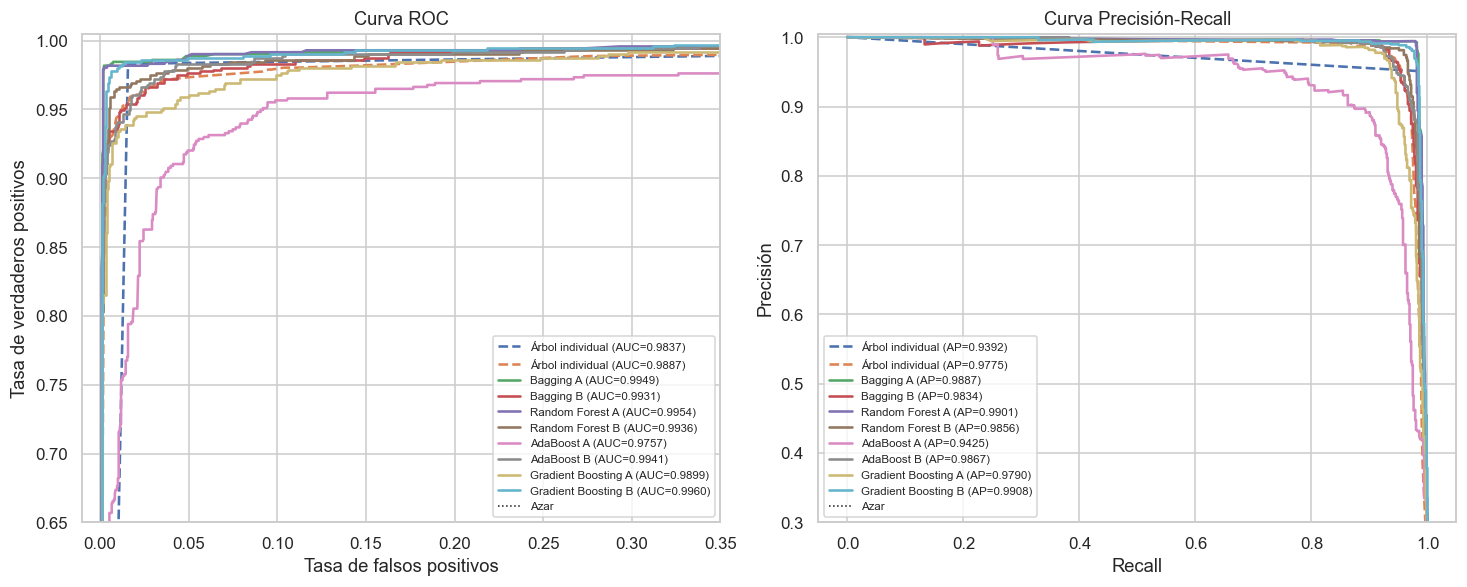

In [29]:
def abreviar(nombre):
    return nombre.split(" - ")[0]


fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))

for nombre, modelo in MODELOS.items():
    y_score = puntuaciones(modelo, X_test)
    estilo = "--" if "Árbol individual" in nombre else "-"
    fpr, tpr, _ = roc_curve(y_test, y_score)
    axes[0].plot(fpr, tpr, estilo, lw=1.7,
                 label=f"{abreviar(nombre)} (AUC={roc_auc_score(y_test, y_score):.4f})")
    prec, rec, _ = precision_recall_curve(y_test, y_score)
    axes[1].plot(rec, prec, estilo, lw=1.7,
                 label=f"{abreviar(nombre)} (AP={average_precision_score(y_test, y_score):.4f})")

axes[0].plot([0, 1], [0, 1], "k:", lw=1, label="Azar")
axes[0].set_xlabel("Tasa de falsos positivos"); axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curva ROC"); axes[0].legend(fontsize=7.5, loc="lower right")
axes[0].set_xlim(-0.01, 0.35); axes[0].set_ylim(0.65, 1.005)

axes[1].axhline((y_test == 1).mean(), color="k", ls=":", lw=1, label="Azar")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precisión")
axes[1].set_title("Curva Precisión-Recall"); axes[1].legend(fontsize=7.5, loc="lower left")
axes[1].set_ylim(0.3, 1.005)

plt.tight_layout()
plt.show()

*Nota*: el eje de la curva ROC está recortado a la esquina superior izquierda porque con AUC por encima de 0.98
todas las curvas se amontonan contra el borde y a escala completa serían indistinguibles.

## 3.2 Matrices de confusión

La tabla de métricas resume, pero es la matriz de confusión la que traduce el resultado a unidades de negocio:
cuántos empleados que se iban no detectamos (**falsos negativos**, el error caro) y en cuántos gastamos una acción
de retención innecesaria (**falsos positivos**).

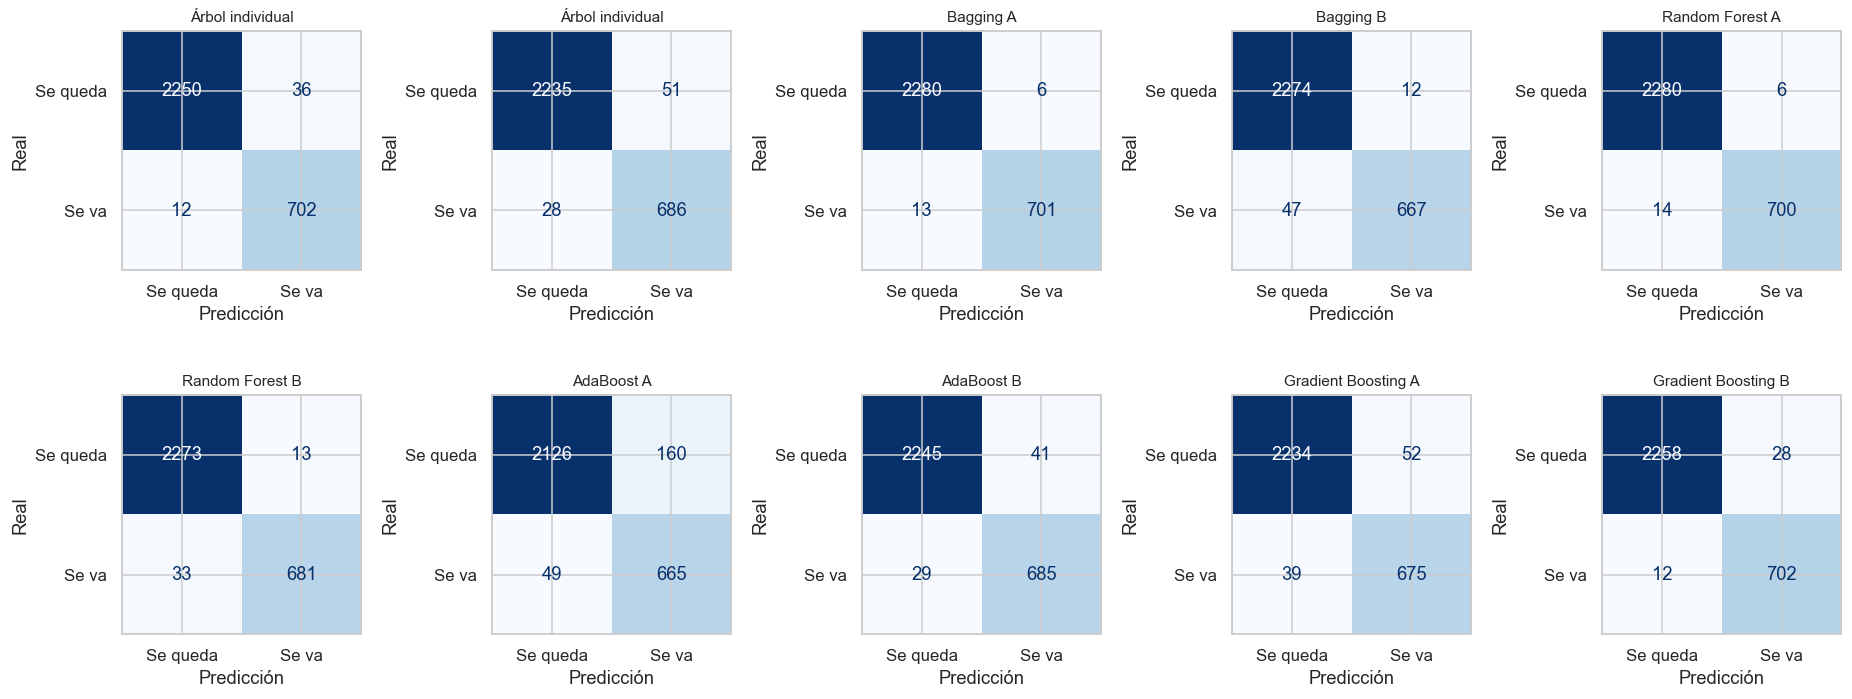

,FN,FP,recall,precision,f1,errores_totales
modelo,,,,,,
Bagging A - 200 árboles completos,13,6,0.9818,0.9915,0.9866,19
"Random Forest A - 300 árboles, max_features='sqrt'",14,6,0.9804,0.9915,0.9859,20
"Gradient Boosting B - 500 árboles, lr=0.05, depth=5, subsample=0.8",12,28,0.9832,0.9616,0.9723,40
"Random Forest B - 300 árboles podados, max_features=None",33,13,0.9538,0.9813,0.9673,46
Árbol individual - sin poda (sprint 2),12,36,0.9832,0.9512,0.9669,48
"Bagging B - 300 árboles podados, 60% filas y columnas",47,12,0.9342,0.9823,0.9576,59
"AdaBoost B - 300 árboles max_depth=5, lr=0.5",29,41,0.9594,0.9435,0.9514,70
Árbol individual - max_depth=12 (sprint 2),28,51,0.9608,0.9308,0.9456,79
"Gradient Boosting A - 200 árboles, lr=0.1, depth=3",39,52,0.9454,0.9285,0.9368,91


In [30]:
nombres = list(MODELOS)
filas = int(np.ceil(len(nombres) / 5))
fig, axes = plt.subplots(filas, 5, figsize=(17, 3.4 * filas))
for ax, nombre in zip(axes.ravel(), nombres):
    matriz_confusion(MODELOS[nombre], abreviar(nombre), ax=ax)
for ax in axes.ravel()[len(nombres):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

(tabla[["FN", "FP", "recall", "precision", "f1"]]
 .assign(errores_totales=lambda t: t["FN"] + t["FP"])
 .sort_values("errores_totales")
 .round(4))

## 3.3 ¿Son reales las diferencias? Validación cruzada

Las métricas anteriores se miden sobre **una única partición de test de 3.000 empleados**. Diferencias de milésimas
en F1 pueden ser simple ruido de muestreo. Para decidir con fundamento repetimos la medición con validación cruzada
estratificada de 5 *folds* sobre el conjunto de entrenamiento y miramos la **dispersión entre folds**: si dos
modelos distan menos que su desviación típica, no hay evidencia de que uno sea mejor que el otro.

In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_filas = []
for nombre, modelo in MODELOS.items():
    t0 = time.time()
    puntos = cross_val_score(clone(modelo), X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    cv_filas.append({"modelo": nombre,
                     "f1_cv_media": puntos.mean(),
                     "f1_cv_desv": puntos.std(),
                     "f1_test": tabla.loc[nombre, "f1"],
                     "t_cv_s": time.time() - t0})

cv_tabla = pd.DataFrame(cv_filas).set_index("modelo").sort_values("f1_cv_media", ascending=False)
cv_tabla.round(4)

,f1_cv_media,f1_cv_desv,f1_test,t_cv_s
modelo,,,,
"Random Forest A - 300 árboles, max_features='sqrt'",0.9733,0.0064,0.9859,4.5694
Bagging A - 200 árboles completos,0.9725,0.0029,0.9866,6.4903
"Gradient Boosting B - 500 árboles, lr=0.05, depth=5, subsample=0.8",0.9699,0.0065,0.9723,11.3646
"Random Forest B - 300 árboles podados, max_features=None",0.9563,0.0094,0.9673,8.6948
"Bagging B - 300 árboles podados, 60% filas y columnas",0.9560,0.0073,0.9576,5.8834
"AdaBoost B - 300 árboles max_depth=5, lr=0.5",0.9539,0.0071,0.9514,8.0147
Árbol individual - sin poda (sprint 2),0.9520,0.0054,0.9669,0.1714
"Gradient Boosting A - 200 árboles, lr=0.1, depth=3",0.9402,0.0089,0.9368,3.4790
Árbol individual - max_depth=12 (sprint 2),0.9354,0.0054,0.9456,0.1744


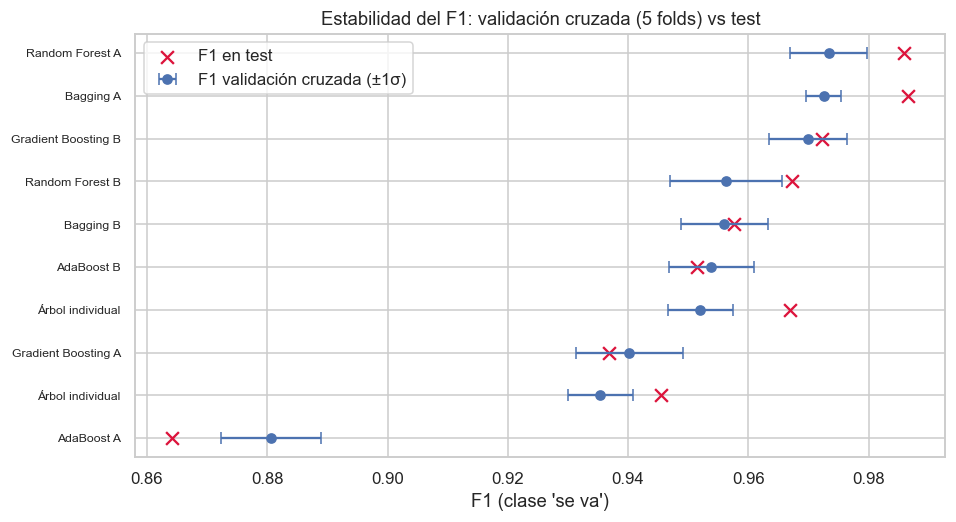

In [32]:
orden = cv_tabla.index[::-1]
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.errorbar(cv_tabla.loc[orden, "f1_cv_media"], range(len(orden)),
            xerr=cv_tabla.loc[orden, "f1_cv_desv"], fmt="o", capsize=4,
            label="F1 validación cruzada (±1σ)")
ax.scatter(cv_tabla.loc[orden, "f1_test"], range(len(orden)), marker="x", s=70,
           color="crimson", label="F1 en test")
ax.set_yticks(range(len(orden)))
ax.set_yticklabels([abreviar(i) for i in orden], fontsize=8)
ax.set_xlabel("F1 (clase 'se va')")
ax.set_title("Estabilidad del F1: validación cruzada (5 folds) vs test")
ax.legend()
plt.show()

## 3.4 Coste de entrenamiento

A igualdad de resultados, el modelo más barato es preferible. Y en boosting el coste no es un detalle menor: al ser
un algoritmo **secuencial** no se puede paralelizar, mientras que el bagging reparte sus árboles entre todos los
núcleos disponibles con `n_jobs=-1`.

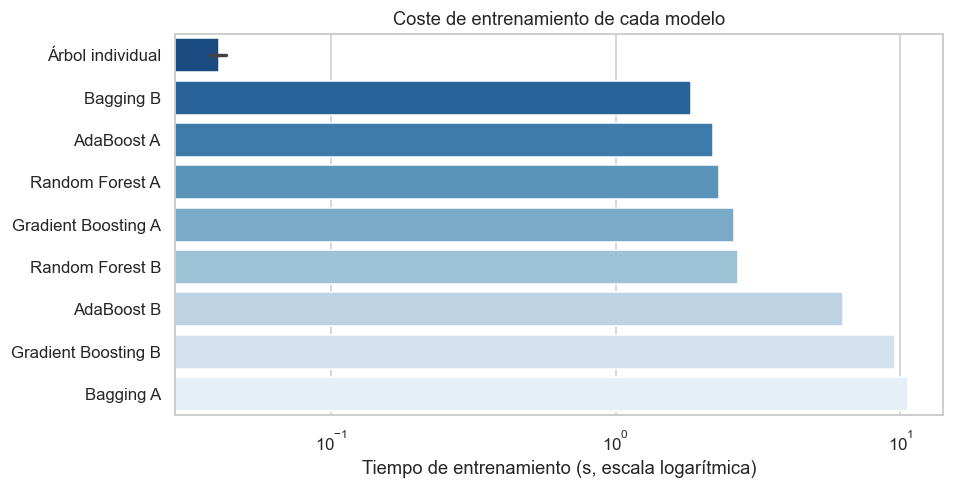

In [33]:
fig, ax = plt.subplots(figsize=(9, 4.5))
tiempos = tabla["t_entren_s"].dropna().sort_values()
etiquetas = [abreviar(i) for i in tiempos.index]
sns.barplot(x=tiempos.values, y=etiquetas, ax=ax, hue=etiquetas, palette="Blues_r", legend=False)
ax.set_xscale("log")
ax.set_xlabel("Tiempo de entrenamiento (s, escala logarítmica)")
ax.set_title("Coste de entrenamiento de cada modelo")
plt.show()

## 3.5 Elección del mejor ensemble

In [34]:
solo_ensembles = tabla.drop(index=[REF_ARBOL, REF_PODADO])
MEJOR_NOMBRE = solo_ensembles["f1"].idxmax()
MEJOR = MODELOS[MEJOR_NOMBRE]

print(f"Mejor ensemble por F1 en test: {MEJOR_NOMBRE}")
print()
print(solo_ensembles.loc[MEJOR_NOMBRE].round(4).to_string())
print()
print("Mejora sobre el mejor árbol individual del sprint 2:")
delta = solo_ensembles.loc[MEJOR_NOMBRE, ["f1", "recall", "precision", "roc_auc", "pr_auc"]] - \
        tabla.loc[REF_ARBOL, ["f1", "recall", "precision", "roc_auc", "pr_auc"]]
print(delta.round(4).to_string())
print()
print(f"Falsos negativos: {int(tabla.loc[REF_ARBOL, 'FN'])} (árbol) -> "
      f"{int(solo_ensembles.loc[MEJOR_NOMBRE, 'FN'])} (mejor ensemble)")

Mejor ensemble por F1 en test: Bagging A - 200 árboles completos

accuracy       0.9937
precision      0.9915
recall         0.9818
f1             0.9866
roc_auc        0.9949
pr_auc         0.9887
f1_train       1.0000
gap_f1         0.0134
FN            13.0000
FP             6.0000
t_entren_s    10.6267

Mejora sobre el mejor árbol individual del sprint 2:
f1           0.0197
recall      -0.0014
precision    0.0403
roc_auc      0.0112
pr_auc       0.0495

Falsos negativos: 12 (árbol) -> 13 (mejor ensemble)


### Discusión de la cuestión 3: el mejor ensemble

**Ranking completo por F1 en test**, con la validación cruzada al lado para saber de qué diferencias nos podemos
fiar:

| # | Modelo | F1 test | F1 CV (5 folds) | Recall | Precisión | PR-AUC | FN | FP | Errores | Tiempo |
|---|---|---|---|---|---|---|---|---|---|---|
| 1 | **Bagging A** (200 árboles completos) | **0.9866** | 0.9725 ± 0.0029 | 0.9818 | **0.9915** | 0.9887 | 13 | **6** | **19** | 8.2 s |
| 2 | **Random Forest A** (`sqrt`) | 0.9859 | **0.9733 ± 0.0064** | 0.9804 | **0.9915** | 0.9901 | 14 | **6** | 20 | **2.1 s** |
| 3 | **Gradient Boosting B** | 0.9723 | 0.9699 ± 0.0065 | **0.9832** | 0.9616 | **0.9908** | **12** | 28 | 40 | 9.3 s |
| 4 | Random Forest B (podado) | 0.9673 | 0.9563 ± 0.0094 | 0.9538 | 0.9813 | 0.9856 | 33 | 13 | 46 | 2.3 s |
| - | *Árbol individual sin poda (sprint 2)* | *0.9669* | *0.9520 ± 0.0054* | *0.9832* | *0.9512* | *0.9392* | *12* | *36* | *48* | *0.03 s* |
| 5 | Bagging B (podado, 60/60) | 0.9576 | 0.9560 ± 0.0073 | 0.9342 | 0.9823 | 0.9834 | 47 | 12 | 59 | 1.7 s |
| 6 | AdaBoost B (depth=5) | 0.9514 | 0.9539 ± 0.0071 | 0.9594 | 0.9435 | 0.9867 | 29 | 41 | 70 | 6.5 s |
| - | *Árbol individual podado (sprint 2)* | *0.9456* | *0.9354 ± 0.0054* | *0.9608* | *0.9308* | *0.9775* | *28* | *51* | *79* | *0.03 s* |
| 7 | Gradient Boosting A | 0.9368 | 0.9402 ± 0.0089 | 0.9454 | 0.9285 | 0.9790 | 39 | 52 | 91 | 2.4 s |
| 8 | AdaBoost A (*stumps*) | 0.8642 | 0.8806 ± 0.0084 | 0.9314 | 0.8061 | 0.9425 | 49 | 160 | 209 | 2.0 s |

**1. El mejor ensemble por poder predictivo es el Bagging A: 200 árboles de decisión completos, F1 = 0.9866.**
Comete **19 errores en 3.000 empleados** (13 falsos negativos y 6 falsos positivos) frente a los 48 del mejor árbol
individual del sprint 2. En términos de negocio: de cada 100 alertas que emite, más de 99 son correctas.

**2. Pero los tres primeros son estadísticamente indistinguibles, y hay que decirlo.** En validación cruzada,
Random Forest A obtiene 0.9733 ± 0.0064, Bagging A 0.9725 ± 0.0029 y Gradient Boosting B 0.9699 ± 0.0065. Las
diferencias entre ellos (0.0008 y 0.0026) son **más pequeñas que la desviación entre folds**, así que no hay
evidencia de que uno sea mejor que otro: el orden del podio depende de qué partición nos haya tocado. Obsérvese
además que la validación cruzada **invierte** el orden de los dos primeros respecto al test.

Por eso, si hubiera que llevar un modelo a producción, **el candidato sería el Random Forest A**: empata en acierto,
tiene la mejor media en validación cruzada, el mejor OOB (0.9900) y **entrena 4 veces más rápido** (2,1 s frente a
8,2 s). Elegir el Bagging A por 0.0007 puntos de F1 sería quedarse con la tercera cifra decimal de una única
partición.

**3. La mejora sobre el sprint 2 es real, pero hay que describirla con precisión.** Frente al árbol individual sin
poda: F1 +0.0197, precisión +0.0403, ROC-AUC +0.0112 y **PR-AUC +0.0495**; el recall, en cambio, baja
imperceptiblemente (-0.0014) y los falsos negativos pasan de 12 a 13.

Es decir: **el ensemble no detecta más bajas que el árbol, detecta las mismas con muchísimo menos ruido**
(36 → 6 falsos positivos). La ganancia está en la fiabilidad de la alerta y en la calidad del *ranking*, no en la
cobertura. Es coherente con la teoría: el bagging ataca la varianza, y la varianza es lo que producía esas hojas
espurias que marcaban como "se va" a empleados que no lo estaban.

**4. Ser un ensemble no garantiza nada: dos de los ocho quedan por debajo del árbol individual.** Gradient
Boosting A (0.9368) y AdaBoost A (0.8642) pierden contra un árbol de decisión sencillo de 0,03 s. La conclusión
práctica es que **el modelo base y sus hiperparámetros importan más que la etiqueta "ensemble"**, y que las dos
familias piden cosas opuestas:

> **Bagging**: árboles **profundos y sin podar**, porque el promedio elimina varianza pero no sesgo.
> **Boosting**: árboles **pequeños**, pero **no tanto como para no poder representar la estructura del problema**.

**5. La curva Precisión-Recall ordena los modelos mejor que la ROC.** Todos los ROC-AUC están entre 0.976 y 0.996 y
las curvas se amontonan contra la esquina; el PR-AUC, en cambio, separa con claridad (de 0.9392 del árbol a 0.9908
de Gradient Boosting B). Es la razón por la que en un problema desbalanceado conviene mirar la segunda: la ROC
promedia sobre una clase mayoritaria que es fácil de acertar.

**6. La elección depende del uso, y el podio cambia según el criterio:**

| Si el objetivo es... | El modelo es... | Porque... |
|---|---|---|
| **Máximo acierto global** | Bagging A / Random Forest A | F1 0.986, solo 19-20 errores en 3.000 |
| **No dejar escapar a nadie** | Gradient Boosting B | 12 falsos negativos, el mínimo, y recall 0.9832 |
| **Priorizar por riesgo** (lista para RRHH) | Gradient Boosting B | PR-AUC 0.9908 y ROC-AUC 0.9960, los mejores |
| **Producción / reentrenamiento frecuente** | Random Forest A | mismo acierto, 4x más rápido, paralelizable |
| **Explicar al cliente** | el árbol podado del sprint 2 | ningún ensemble es legible; ver punto 7 |

**7. El precio que se ha pagado: la caja blanca.** Conviene ponerlo encima de la mesa, porque es la contrapartida
directa del sprint anterior. El cliente pidió árboles de decisión *porque quería entender el modelo*, y lo que
tenemos ahora es un comité de 200 árboles de 20 niveles cada uno: predice mejor, pero **ya no se puede leer**. Lo
único que sobrevive de la interpretabilidad es la importancia de atributos -que es justo lo que analiza la
cuestión 4- y esa es una explicación mucho más pobre que las reglas del sprint 2.

La recomendación razonable para el cliente es **usar los dos**: el ensemble para puntuar y priorizar, y el árbol
podado de profundidad 3 del sprint 2 como "mapa" que explica en una diapositiva cuál es la lógica del fenómeno.
Cuestan 0,03 s de entrenar y responden a preguntas distintas.

# CUESTIÓN 4 - Variables más relevantes del modelo

Tercera parte del enunciado: **obtener las variables más relevantes y discutir si tiene sentido que sean las de
mayor peso**. Es la cuestión que más le interesa al cliente, porque es la que traduce el modelo a decisiones de
RRHH.

Usamos dos medidas complementarias, porque **miden cosas distintas y la primera tiene un sesgo conocido**:

* **Importancia por impureza** (`feature_importances_`, también llamada MDI, *mean decrease in impurity*): suma
  ponderada de la reducción de impureza que aporta cada atributo en los cortes donde interviene, promediada sobre
  todos los árboles del ensemble. Es la que sale gratis, pero **favorece a las variables continuas y de alta
  cardinalidad** (tienen más puntos de corte candidatos) y se calcula sobre el conjunto de **entrenamiento**, así
  que puede premiar a una variable que solo sirvió para memorizar.
* **Importancia por permutación** (`permutation_importance`): se mide cuánto **empeora el F1 en el conjunto de
  test** al barajar aleatoriamente los valores de una variable. No depende de la estructura interna del modelo, se
  mide sobre datos no vistos y responde directamente a la pregunta "¿cuánto me costaría perder esta variable?".

Si ambas coinciden, la conclusión es sólida.

## 4.1 Importancia por impureza en el mejor ensemble

Un detalle técnico: `BaggingClassifier` **no expone `feature_importances_`** (a diferencia de `RandomForest`,
`AdaBoost` y `GradientBoosting`). Hay que promediarlas a mano sobre sus árboles base, teniendo en cuenta que con
`max_features<1.0` cada árbol solo ha visto un subconjunto de atributos y su vector de importancias está indexado
sobre ese subconjunto: `estimators_features_` guarda la correspondencia.

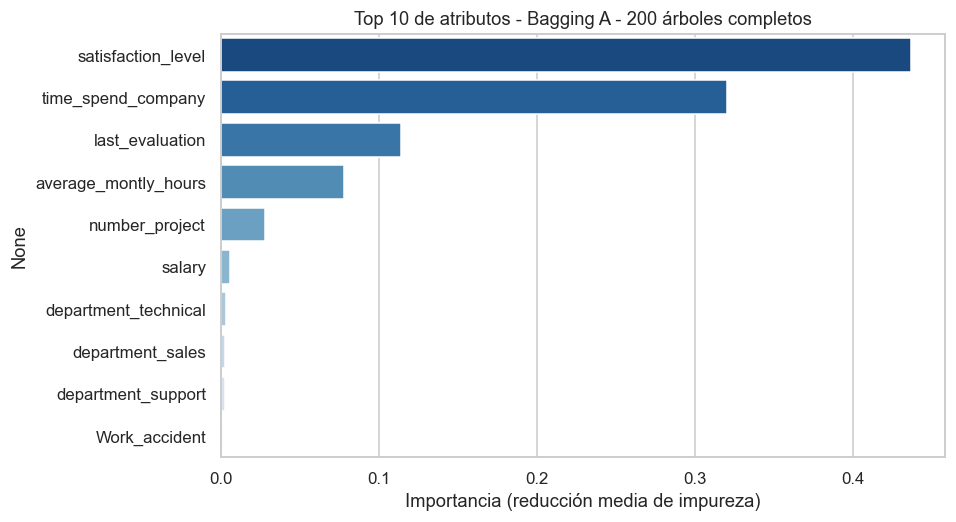

satisfaction_level      0.4364
time_spend_company      0.3202
last_evaluation         0.1144
average_montly_hours    0.0780
number_project          0.0281
salary                  0.0062
department_technical    0.0036
department_sales        0.0028
department_support      0.0025
Work_accident           0.0018

Las 4 primeras variables acumulan el 94.9% de la importancia total.
Las variables de departamento suman en conjunto 1.45%.


In [35]:
def importancias(modelo):
    """Serie de importancias por impureza, indexada por nombre de atributo.

    Funciona tanto para los ensembles que exponen feature_importances_ como para
    BaggingClassifier, que no lo hace y hay que promediar a mano sobre sus árboles.
    """
    if hasattr(modelo, "feature_importances_"):
        valores = modelo.feature_importances_
    elif isinstance(modelo, BaggingClassifier):
        acumulado = np.zeros(len(FEATURES))
        for est, feats in zip(modelo.estimators_, modelo.estimators_features_):
            acumulado[np.asarray(feats)] += est.feature_importances_
        valores = acumulado / len(modelo.estimators_)
    else:
        raise TypeError(f"{type(modelo).__name__} no permite calcular importancias por impureza")
    return pd.Series(valores, index=FEATURES).sort_values(ascending=False)


imp_mejor = importancias(MEJOR)

fig, ax = plt.subplots(figsize=(8.5, 5))
top = imp_mejor.head(10)
sns.barplot(x=top.values, y=top.index, ax=ax, hue=top.index, palette="Blues_r", legend=False)
ax.set_xlabel("Importancia (reducción media de impureza)")
ax.set_title(f"Top 10 de atributos - {MEJOR_NOMBRE}")
plt.show()

print(imp_mejor.head(10).round(4).to_string())
print()
print(f"Las 4 primeras variables acumulan el {imp_mejor.head(4).sum():.1%} de la importancia total.")
print(f"Las variables de departamento suman en conjunto "
      f"{imp_mejor[[f for f in FEATURES if f.startswith('department_')]].sum():.2%}.")

## 4.2 ¿Coinciden todos los ensembles en las variables importantes?

Si los ocho modelos -entrenados con algoritmos y configuraciones muy distintas- señalan a las mismas variables, el
resultado es del problema y no del modelo, que es justo lo que necesitamos para poder afirmarle algo al cliente.

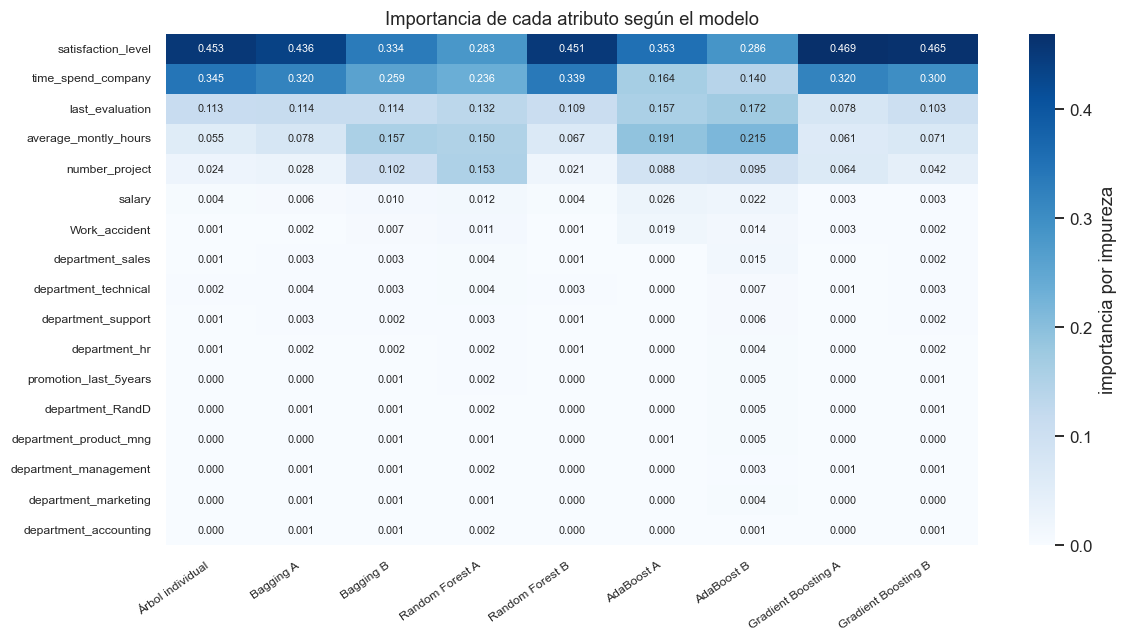

In [36]:
imp_todos = pd.DataFrame({abreviar(n): importancias(m)
                          for n, m in MODELOS.items()
                          if hasattr(m, "feature_importances_") or isinstance(m, BaggingClassifier)})

orden_feats = imp_todos.mean(axis=1).sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(imp_todos.loc[orden_feats], annot=True, fmt=".3f", cmap="Blues",
            cbar_kws={"label": "importancia por impureza"}, ax=ax, annot_kws={"size": 7})
ax.set_title("Importancia de cada atributo según el modelo")
plt.xticks(rotation=35, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [37]:
ranking_medio = (imp_todos.rank(ascending=False).mean(axis=1)
                 .sort_values()
                 .to_frame("posición media en el ranking")
                 .join(imp_todos.mean(axis=1).to_frame("importancia media"))
                 .join(imp_todos.std(axis=1).to_frame("desv. entre modelos")))
ranking_medio.head(10).round(4)

,posición media en el ranking,importancia media,desv. entre modelos
satisfaction_level,1.0000,0.3923,0.0778
time_spend_company,2.3333,0.2691,0.0755
last_evaluation,3.4444,0.1214,0.0285
average_montly_hours,3.5556,0.1160,0.0621
number_project,4.6667,0.0687,0.0447
salary,6.1111,0.0102,0.0087
department_technical,8.2222,0.0030,0.0021
Work_accident,8.4444,0.0066,0.0066
department_sales,9.3333,0.0034,0.0046
department_support,10.4444,0.0020,0.0018


## 4.3 Importancia por permutación (sobre el conjunto de test)

La contraprueba: cuánto cae el **F1 en test** al destruir la información de cada variable barajando sus valores.
Es más costosa de calcular (hay que repredecir muchas veces) pero es la medida honesta, porque se hace sobre datos
que el modelo no ha visto.

Calculado en 9.3 s


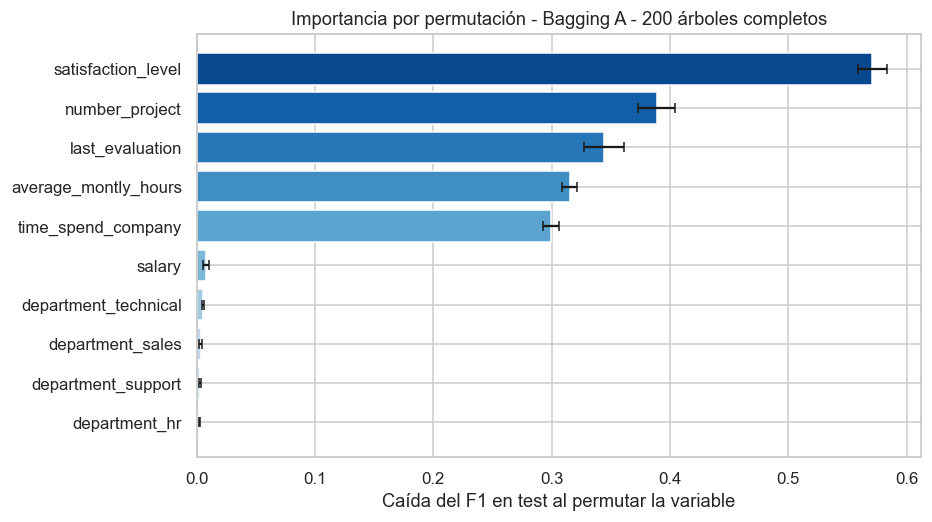

,caida_f1,desv
satisfaction_level,0.5709,0.0121
number_project,0.3888,0.0158
last_evaluation,0.3443,0.0166
average_montly_hours,0.3152,0.0062
time_spend_company,0.2996,0.0071
salary,0.0082,0.0025
department_technical,0.0055,0.0012
department_sales,0.0035,0.0011
department_support,0.0026,0.0009
department_hr,0.0024,0.0006


In [38]:
t0 = time.time()
perm = permutation_importance(MEJOR, X_test, y_test,
                              scoring="f1", n_repeats=10,
                              random_state=RANDOM_STATE, n_jobs=-1)
print(f"Calculado en {time.time() - t0:.1f} s")

perm_df = (pd.DataFrame({"caida_f1": perm.importances_mean,
                         "desv": perm.importances_std}, index=FEATURES)
           .sort_values("caida_f1", ascending=False))

fig, ax = plt.subplots(figsize=(8.5, 5))
top_perm = perm_df.head(10)
ax.barh(top_perm.index[::-1], top_perm["caida_f1"][::-1],
        xerr=top_perm["desv"][::-1], color=sns.color_palette("Blues_r", 10)[::-1], capsize=3)
ax.set_xlabel("Caída del F1 en test al permutar la variable")
ax.set_title(f"Importancia por permutación - {MEJOR_NOMBRE}")
plt.show()

perm_df.head(10).round(4)

In [39]:
comparacion_imp = (pd.DataFrame({"impureza (train)": imp_mejor,
                                 "permutación (test)": perm_df["caida_f1"]})
                   .assign(rank_impureza=lambda t: t["impureza (train)"].rank(ascending=False).astype(int),
                           rank_permutacion=lambda t: t["permutación (test)"].rank(ascending=False).astype(int))
                   .sort_values("impureza (train)", ascending=False))
comparacion_imp.head(10).round(4)

,impureza (train),permutación (test),rank_impureza,rank_permutacion
satisfaction_level,0.4364,0.5709,1,1
time_spend_company,0.3202,0.2996,2,5
last_evaluation,0.1144,0.3443,3,3
average_montly_hours,0.0780,0.3152,4,4
number_project,0.0281,0.3888,5,2
salary,0.0062,0.0082,6,6
department_technical,0.0036,0.0055,7,7
department_sales,0.0028,0.0035,8,8
department_support,0.0025,0.0026,9,9
Work_accident,0.0018,0.0013,10,11


### Discusión de la cuestión 4: ¿tiene sentido que sean las variables con mayor peso?

**Las variables más relevantes del mejor ensemble** (Bagging A), por las dos medidas:

| Variable | Impureza (train) | Rango | Permutación (test) | Rango |
|---|---|---|---|---|
| `satisfaction_level` | **0.4364** | 1 | **0.5709** | 1 |
| `time_spend_company` (antigüedad) | 0.3202 | 2 | 0.2996 | 5 |
| `last_evaluation` | 0.1144 | 3 | 0.3443 | 3 |
| `average_montly_hours` | 0.0780 | 4 | 0.3152 | 4 |
| `number_project` | 0.0281 | 5 | **0.3888** | **2** |
| `salary` | 0.0062 | 6 | 0.0082 | 6 |
| *todas las de departamento juntas* | *0.0145* | - | *~0.015* | - |

**1. Las cinco primeras variables se lo llevan todo.** Las cuatro primeras acumulan el **94,9%** de la importancia
por impureza, y con `number_project` se supera el 97%. Todo lo demás -salario, promociones, accidentes laborales y
las nueve variables de departamento- suma menos del 3%.

**2. Los nueve modelos coinciden, lo que da mucha solidez al resultado.** `satisfaction_level` sale **primera en
los nueve** (posición media 1.00), y el orden medio del resto es antigüedad (2.33), evaluación (3.44), horas
mensuales (3.56) y número de proyectos (4.67). Algoritmos tan distintos como un bagging de árboles completos y un
AdaBoost de tocones señalan a las mismas cinco variables: **esto es una propiedad del problema, no del modelo.**

**3. La discrepancia entre las dos medidas es el hallazgo más interesante: `number_project`.** Es la quinta por
impureza (0.0281, casi despreciable) pero la **segunda por permutación** (una caída de 0.39 puntos de F1 al
barajarla, más que la antigüedad). Las dos razones son conocidas y merece la pena nombrarlas:

* **Sesgo de cardinalidad de la MDI**: `number_project` toma solo 6 valores enteros, así que ofrece 5 puntos de
  corte posibles, frente a los cientos de `satisfaction_level` o `average_montly_hours`. Con menos oportunidades de
  ser elegida, acumula menos reducción de impureza aunque sea igual de informativa.
* **Correlación entre variables**: el número de proyectos, las horas mensuales y la evaluación describen en buena
  medida lo mismo (la carga de trabajo). Cuando dos variables son sustitutivas, los árboles reparten los cortes
  entre ambas y la MDI **diluye** la importancia entre ellas. La permutación no tiene ese problema porque mide
  directamente el daño de perder la variable.

La lección metodológica: **`feature_importances_` es una medida cómoda pero sesgada**, y cuando una decisión de
negocio depende del ranking conviene confirmarlo con permutación sobre datos no vistos.

**4. ¿Tiene sentido que sean estas? Sí, y además coincide con lo que ya sabíamos.** En el sprint 2, el árbol
individual daba 44% a la satisfacción, 33% a la antigüedad, 12% a la evaluación y 6% a las horas. El ensemble da
43,6%, 32,0%, 11,4% y 7,8%. Son prácticamente los mismos números, lo que significa que **el ensemble no ha cambiado
la historia, solo la ha hecho más precisa**: las reglas interpretables que le contamos al cliente en el sprint 2
siguen siendo la explicación correcta de lo que hace el modelo nuevo.

Y esas variables son exactamente las que describen los dos perfiles de fuga del sprint 2:

* **El empleado quemado**: `satisfaction_level` baja + `time_spend_company` de 3 a 4 años. Las dos primeras
  variables de la lista.
* **El empleado valioso sin recorrido**: `satisfaction_level` alta + veterano + `last_evaluation` > 0.8, y con
  sobrecarga (`average_montly_hours`, `number_project`). Las cinco primeras variables.

Que la insatisfacción sea el predictor número uno de una dimisión no sorprende a nadie -y precisamente por eso hay
que decir algo más al respecto, ver el punto 6-. Lo que sí es informativo es el **peso de la carga de trabajo**:
horas mensuales y número de proyectos, juntos, pesan más que la evaluación del desempeño.

**5. Lo que las variables *no* importantes dicen también es relevante.** El **departamento es irrelevante** (1,45%
entre las nueve variables juntas): la rotación es **transversal a la organización**, no es el problema de un área
concreta, y por tanto no se arregla cambiando a un jefe. Y el **salario pesa un 0,6%**, con las promociones casi a
cero. En estos datos, **la gente no se va principalmente por dinero**: se va por desgaste y por falta de horizonte
profesional. Es el mensaje con más consecuencias prácticas de todo el estudio, porque una política de retención
basada en subidas salariales atacaría una variable que el modelo considera casi ruido.

**6. Dos cautelas imprescindibles al interpretar esto.**

* **Importancia no es causalidad.** El modelo dice que `satisfaction_level` es el mejor **predictor** disponible,
  no que la insatisfacción **cause** las bajas. Es una variable de encuesta, y es perfectamente posible que se
  rellene cuando la decisión de marcharse ya está tomada -en cuyo caso estaríamos midiendo la decisión, no su
  causa- o que ambas cosas sean consecuencia de un tercer factor.
* **La importancia se reparte entre variables correlacionadas.** Como acabamos de ver con `number_project`, que una
  variable tenga poco peso no significa que no sea informativa: puede que otra esté diciendo lo mismo. Eliminar del
  modelo las variables de la cola baja del ranking exigiría comprobarlo una a una.

# 5. PARTE OPCIONAL - Un modelo base distinto del árbol de decisión

El enunciado propone usar, en algún método que lo permita (`BaggingClassifier`, `AdaBoostClassifier`), **un modelo
base diferente de los árboles de decisión**, y estudiar su influencia en los resultados **y en la varianza y el
sesgo**.

Elegimos como base la **regresión logística**, y lo hacemos por dos razones:

1. Es el ejemplo del propio notebook de clase de `BaggingClassifier` (bagging sobre un `Pipeline` con
   `StandardScaler` + `LogisticRegression`).
2. Es el modelo **opuesto al árbol** en el eje sesgo-varianza, que es justo lo que interesa para el estudio: una
   frontera lineal es muy **estable** (varianza baja) pero **rígida** (sesgo alto), mientras que el árbol sin podar
   es flexible (sesgo bajo) e inestable (varianza alta). En el sprint 2 ya vimos que la regresión logística se
   hundía en este problema (F1 = 0.6162) precisamente porque la relación no es lineal ni monótona: se marchan tanto
   los muy insatisfechos como los muy satisfechos con mucha antigüedad y buena evaluación.

La hipótesis a contrastar es la teoría vista en clase:

* **El bagging reduce la varianza pero no el sesgo.** Por tanto debería mejorar mucho al árbol (que sufre de
  varianza) y **casi nada a la regresión logística** (que sufre de sesgo): promediar cien rectas casi idénticas
  sigue dando una recta.
* **El boosting reduce el sesgo.** Por tanto sí debería mejorar a la regresión logística, porque la suma ponderada
  de varias fronteras lineales ya no es lineal.

Al ser modelos sensibles a la escala, la regresión logística va siempre dentro de un `Pipeline` con
`StandardScaler`, igual que en el notebook de clase.

> *Detalle técnico*: `AdaBoostClassifier` comprueba que el modelo base acepte `sample_weight` en su `fit`
> -es el mecanismo con el que repondera las muestras- y el `Pipeline` de `scikit-learn` no declara ese parámetro
> en su firma, así que lo rechaza. Lo resolvemos con una subclase mínima de `Pipeline` que lo declara y lo
> reenvía al último paso de la tubería.

## 5.1 Regresión logística: sola, con bagging y con boosting

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


class PipelineConPesos(Pipeline):
    """Pipeline que expone sample_weight en fit y se lo pasa al estimador final.

    Necesario para poder usar un Pipeline como modelo base de AdaBoostClassifier,
    que exige que el weak learner acepte pesos por muestra.
    """

    def fit(self, X, y=None, sample_weight=None, **kwargs):
        if sample_weight is not None:
            kwargs[f"{self.steps[-1][0]}__sample_weight"] = sample_weight
        return super().fit(X, y, **kwargs)


def logit():
    return PipelineConPesos([
        ("escalado", StandardScaler()),
        ("logit", LogisticRegression(class_weight="balanced", max_iter=2000,
                                     random_state=RANDOM_STATE)),
    ])

# --- 1) Modelo base solo, como referencia
logit_solo = logit()
t0 = time.time(); logit_solo.fit(X_train, y_train); t_lg = time.time() - t0
LOGIT = "Regresión logística (sola)"
evaluar(LOGIT, logit_solo, t_lg, familia="Base alternativa", informe=False)

# --- 2) Bagging con base lineal
bag_logit = BaggingClassifier(estimator=logit(), n_estimators=100,
                              max_samples=0.8, max_features=0.8,
                              n_jobs=-1, random_state=RANDOM_STATE)
t0 = time.time(); bag_logit.fit(X_train, y_train); t_bl = time.time() - t0
BAG_LOGIT = "Bagging (base = regresión logística)"
evaluar(BAG_LOGIT, bag_logit, t_bl, familia="Base alternativa", informe=False)

# --- 3) AdaBoost con base lineal
ada_logit = AdaBoostClassifier(estimator=logit(), n_estimators=200,
                               learning_rate=0.5, random_state=RANDOM_STATE)
t0 = time.time(); ada_logit.fit(X_train, y_train); t_al = time.time() - t0
ADA_LOGIT = "AdaBoost (base = regresión logística)"
evaluar(ADA_LOGIT, ada_logit, t_al, familia="Base alternativa", informe=False)

tabla_alternativa = tabla_resultados(["Base alternativa"])
tabla_alternativa.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc,f1_train,gap_f1,FN,FP,t_entren_s
modelo,,,,,,,,,,,
Regresión logística (sola),0.7617,0.4996,0.8039,0.6162,0.8249,0.4792,0.6124,-0.0038,140,575,0.0233
Bagging (base = regresión logística),0.7597,0.4969,0.7969,0.6122,0.8265,0.4921,0.6099,-0.0022,145,576,0.4734
AdaBoost (base = regresión logística),0.7647,0.5036,0.7801,0.6121,0.8165,0.4885,0.6060,-0.0061,157,549,0.3059


Antes de interpretar la tabla conviene mirar **cuántos modelos ha llegado a entrenar realmente AdaBoost** con base
lineal, y con qué peso (`estimator_weights_`, el coeficiente α con el que cada modelo vota) los ha incorporado.

In [41]:
print(f"AdaBoost(reg. logística): {len(ada_logit)} modelos entrenados de los "
      f"{ada_logit.n_estimators} solicitados")
print("Pesos (alfa) de los primeros modelos:", np.round(ada_logit.estimator_weights_[:8], 3))
print()
print(f"AdaBoost(árboles depth=5): {len(ada_b)} modelos entrenados de los "
      f"{ada_b.n_estimators} solicitados")
print("Pesos (alfa) de los primeros modelos:", np.round(ada_b.estimator_weights_[:8], 3))

AdaBoost(reg. logística): 12 modelos entrenados de los 200 solicitados
Pesos (alfa) de los primeros modelos: [0.529 0.325 0.208 0.138 0.107 0.099 0.093 0.072]

AdaBoost(árboles depth=5): 300 modelos entrenados de los 300 solicitados
Pesos (alfa) de los primeros modelos: [1.412 1.064 0.737 0.607 0.389 0.366 0.296 0.336]


In [42]:
comparacion_base = tabla_resultados()[["f1", "recall", "precision", "roc_auc", "pr_auc", "gap_f1"]].loc[[
    REF_ARBOL, BAG_A, ADA_A,
    LOGIT, BAG_LOGIT, ADA_LOGIT,
]]
comparacion_base.insert(0, "modelo base", ["Árbol", "Árbol", "Árbol",
                                           "Reg. logística", "Reg. logística", "Reg. logística"])
comparacion_base.insert(1, "ensemble", ["ninguno", "Bagging", "AdaBoost",
                                        "ninguno", "Bagging", "AdaBoost"])
comparacion_base.round(4)

,modelo base,ensemble,f1,recall,precision,roc_auc,pr_auc,gap_f1
modelo,,,,,,,,
Árbol individual - sin poda (sprint 2),Árbol,ninguno,0.9669,0.9832,0.9512,0.9837,0.9392,0.0331
Bagging A - 200 árboles completos,Árbol,Bagging,0.9866,0.9818,0.9915,0.9949,0.9887,0.0134
"AdaBoost A - 300 stumps (max_depth=1), lr=1.0",Árbol,AdaBoost,0.8642,0.9314,0.8061,0.9757,0.9425,0.0150
Regresión logística (sola),Reg. logística,ninguno,0.6162,0.8039,0.4996,0.8249,0.4792,-0.0038
Bagging (base = regresión logística),Reg. logística,Bagging,0.6122,0.7969,0.4969,0.8265,0.4921,-0.0022
AdaBoost (base = regresión logística),Reg. logística,AdaBoost,0.6121,0.7801,0.5036,0.8165,0.4885,-0.0061


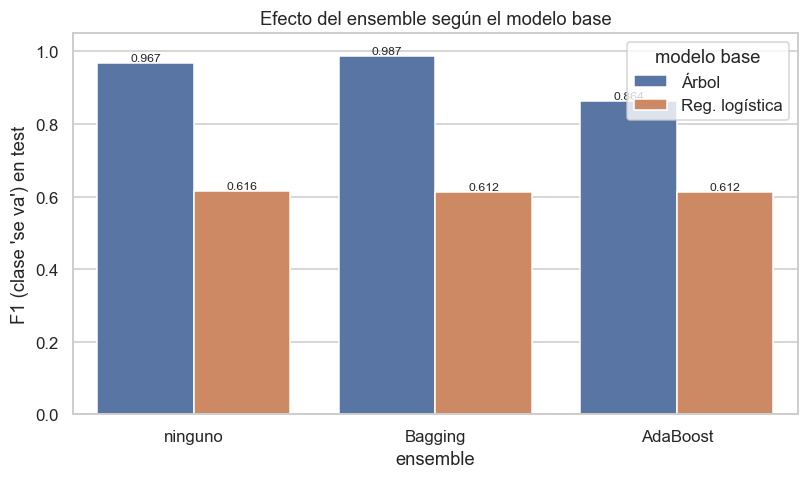

In [43]:
resumen = comparacion_base.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.barplot(data=resumen, x="ensemble", y="f1", hue="modelo base", ax=ax,
            order=["ninguno", "Bagging", "AdaBoost"])
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.3f", fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1 (clase 'se va') en test")
ax.set_title("Efecto del ensemble según el modelo base")
plt.show()

## 5.2 Descomposición sesgo-varianza

Comparar F1 no basta para hablar de sesgo y varianza: hay que **medirlos**. Aplicamos la descomposición clásica del
error 0-1 (Domingos, 2000), que es la versión para clasificación de la descomposición
*error = sesgo² + varianza + ruido*:

1. Se generan **B conjuntos de entrenamiento distintos** por remuestreo *bootstrap* del original. Cada uno simula
   "otra muestra que podríamos haber recogido".
2. Se entrena el mismo algoritmo en cada uno y se predice el conjunto de test.
3. Para cada empleado del test:
   * la **predicción principal** es la clase que más veces predicen los B modelos (voto mayoritario);
   * el **sesgo** vale 1 si esa predicción principal es incorrecta → *error sistemático del algoritmo*, el que
     cometería aunque tuviese datos perfectos;
   * la **varianza** es la proporción de los B modelos que se apartan de la predicción principal → *inestabilidad
     frente a cambios en los datos de entrenamiento*.
4. El **error medio** es la tasa de fallo promedio de los B modelos, y se descompone en esos dos términos.

Un algoritmo con sesgo alto se equivoca siempre igual; uno con varianza alta se equivoca de forma distinta cada vez
que le cambias los datos.

In [44]:
def sesgo_varianza(estimador, B=15, semilla=RANDOM_STATE):
    """Descomposición sesgo-varianza del error 0-1 (Domingos) mediante B remuestreos bootstrap."""
    predicciones = np.empty((B, len(y_test)), dtype=int)
    for b in range(B):
        Xb, yb = resample(X_train, y_train, replace=True, random_state=semilla + b)
        modelo = clone(estimador).fit(Xb, yb)
        predicciones[b] = modelo.predict(X_test)

    # Predicción principal: voto mayoritario de los B modelos, empleado a empleado
    principal = (predicciones.mean(axis=0) >= 0.5).astype(int)

    error = (predicciones != y_test).mean()            # error medio de los B modelos
    sesgo = (principal != y_test).mean()               # error de la predicción principal
    varianza = (predicciones != principal).mean()      # desacuerdo medio con la predicción principal
    return {"error": error, "sesgo": sesgo, "varianza": varianza}


CANDIDATOS_BV = {
    "Árbol sin poda":            DecisionTreeClassifier(class_weight="balanced",
                                                        random_state=RANDOM_STATE),
    "Árbol max_depth=3":         DecisionTreeClassifier(class_weight="balanced", max_depth=3,
                                                        random_state=RANDOM_STATE),
    "Bagging (árboles)":         clone(bagging_a),
    "Random Forest":             clone(rf_a),
    "AdaBoost (stumps)":         clone(ada_a),
    "Gradient Boosting":         GBPonderado(n_estimators=150, learning_rate=0.1, max_depth=3,
                                             random_state=RANDOM_STATE),
    "Reg. logística":            logit(),
    "Bagging (reg. logística)":  clone(bag_logit),
    "AdaBoost (reg. logística)": clone(ada_logit),
}

filas_bv = []
for nombre, est in CANDIDATOS_BV.items():
    t0 = time.time()
    fila = sesgo_varianza(est)
    fila["modelo"] = nombre
    fila["t_s"] = time.time() - t0
    filas_bv.append(fila)
    print(f"{nombre:28s} error={fila['error']:.4f}  sesgo={fila['sesgo']:.4f}  "
          f"varianza={fila['varianza']:.4f}  ({fila['t_s']:.1f} s)")

bv = pd.DataFrame(filas_bv).set_index("modelo")[["error", "sesgo", "varianza"]]
bv.round(4)

Árbol sin poda               error=0.0249  sesgo=0.0080  varianza=0.0195  (0.7 s)


Árbol max_depth=3            error=0.0920  sesgo=0.0903  varianza=0.0024  (0.3 s)


Bagging (árboles)            error=0.0133  sesgo=0.0080  varianza=0.0073  (30.9 s)


Random Forest                error=0.0120  sesgo=0.0087  varianza=0.0056  (41.6 s)


AdaBoost (stumps)            error=0.0670  sesgo=0.0680  varianza=0.0106  (37.7 s)


Gradient Boosting            error=0.0348  sesgo=0.0330  varianza=0.0086  (31.5 s)


Reg. logística               error=0.2392  sesgo=0.2397  varianza=0.0161  (0.4 s)


Bagging (reg. logística)     error=0.2397  sesgo=0.2390  varianza=0.0164  (10.4 s)


AdaBoost (reg. logística)    error=0.2375  sesgo=0.2383  varianza=0.0194  (7.8 s)


,error,sesgo,varianza
modelo,,,
Árbol sin poda,0.0249,0.0080,0.0195
Árbol max_depth=3,0.0920,0.0903,0.0024
Bagging (árboles),0.0133,0.0080,0.0073
Random Forest,0.0120,0.0087,0.0056
AdaBoost (stumps),0.0670,0.0680,0.0106
Gradient Boosting,0.0348,0.0330,0.0086
Reg. logística,0.2392,0.2397,0.0161
Bagging (reg. logística),0.2397,0.2390,0.0164
AdaBoost (reg. logística),0.2375,0.2383,0.0194


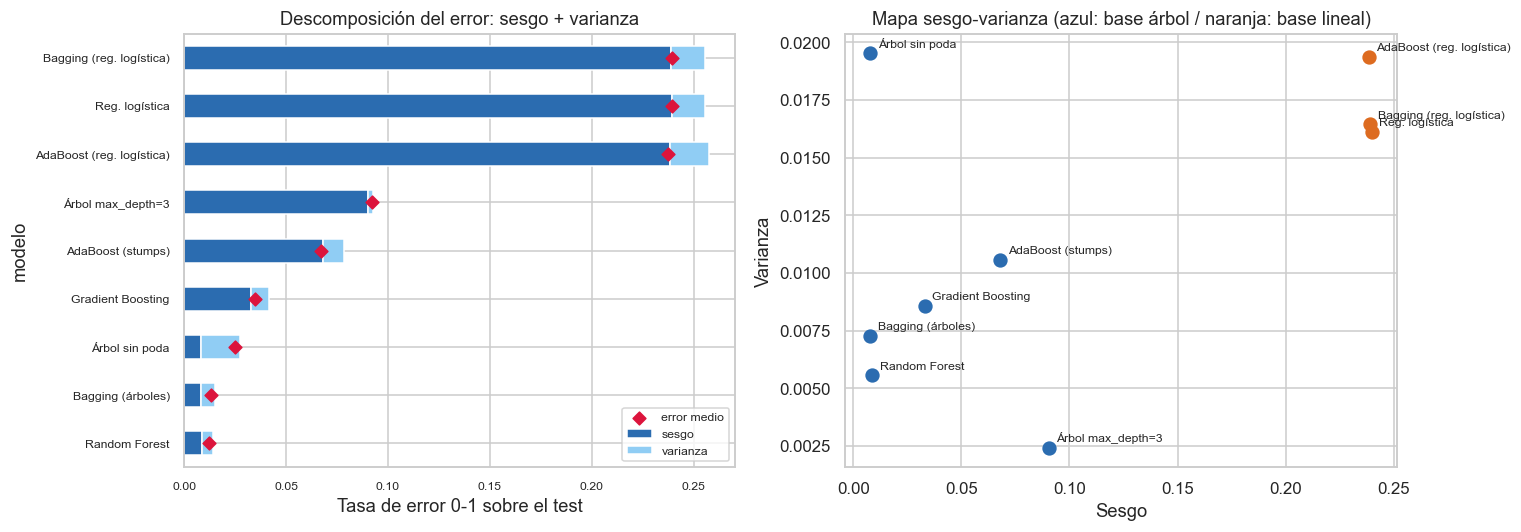

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden_bv = bv.sort_values("error").index
bv.loc[orden_bv, ["sesgo", "varianza"]].plot(kind="barh", stacked=True, ax=axes[0],
                                             color=["#2b6cb0", "#90cdf4"])
axes[0].scatter(bv.loc[orden_bv, "error"], range(len(orden_bv)), marker="D", color="crimson",
                s=35, zorder=3, label="error medio")
axes[0].set_xlabel("Tasa de error 0-1 sobre el test")
axes[0].set_title("Descomposición del error: sesgo + varianza")
axes[0].legend(fontsize=8)
axes[0].tick_params(labelsize=8)

for nombre in bv.index:
    color = "#2b6cb0" if "logística" not in nombre else "#dd6b20"
    axes[1].scatter(bv.loc[nombre, "sesgo"], bv.loc[nombre, "varianza"], s=70, color=color)
    axes[1].annotate(nombre, (bv.loc[nombre, "sesgo"], bv.loc[nombre, "varianza"]),
                     fontsize=8, xytext=(5, 4), textcoords="offset points")
axes[1].set_xlabel("Sesgo"); axes[1].set_ylabel("Varianza")
axes[1].set_title("Mapa sesgo-varianza (azul: base árbol / naranja: base lineal)")

plt.tight_layout()
plt.show()

Y la lectura que interesa para responder al enunciado: **cuánto mueve cada tipo de ensemble el sesgo y la varianza
de su propio modelo base**. Las columnas `Δ` son la diferencia respecto al modelo base sin ensamblar, así que un
valor negativo significa "el ensemble ha reducido ese término".

Cada ensemble se compara con **el modelo base que realmente usa**, que es lo único que hace justa la comparación:
el bagging de la sección 1.1 se construye sobre árboles sin podar, mientras que AdaBoost A se construye sobre
*stumps*, cuyo pariente más cercano en la tabla es el árbol de profundidad 3.

In [46]:
PAREJAS = [
    ("Árbol sin poda",             "Árbol sin poda",            None),
    ("  + Bagging",                "Bagging (árboles)",         "Árbol sin poda"),
    ("  + Random Forest",          "Random Forest",             "Árbol sin poda"),
    ("Árbol poco profundo",        "Árbol max_depth=3",         None),
    ("  + AdaBoost (stumps)",      "AdaBoost (stumps)",         "Árbol max_depth=3"),
    ("  + Gradient Boosting",      "Gradient Boosting",         "Árbol max_depth=3"),
    ("Reg. logística",             "Reg. logística",            None),
    ("  + Bagging",                "Bagging (reg. logística)",  "Reg. logística"),
    ("  + AdaBoost",               "AdaBoost (reg. logística)", "Reg. logística"),
]

efecto = pd.DataFrame(
    [{"combinación": etiqueta,
      "sesgo": bv.loc[fila, "sesgo"],
      "varianza": bv.loc[fila, "varianza"],
      "error": bv.loc[fila, "error"],
      "Δ sesgo vs base": np.nan if base is None else bv.loc[fila, "sesgo"] - bv.loc[base, "sesgo"],
      "Δ varianza vs base": np.nan if base is None else bv.loc[fila, "varianza"] - bv.loc[base, "varianza"]}
     for etiqueta, fila, base in PAREJAS]
).set_index("combinación")

efecto.round(4)

,sesgo,varianza,error,Δ sesgo vs base,Δ varianza vs base
combinación,,,,,
Árbol sin poda,0.0080,0.0195,0.0249,NaN,NaN
+ Bagging,0.0080,0.0073,0.0133,0.0000,-0.0122
+ Random Forest,0.0087,0.0056,0.0120,0.0007,-0.0140
Árbol poco profundo,0.0903,0.0024,0.0920,NaN,NaN
+ AdaBoost (stumps),0.0680,0.0106,0.0670,-0.0223,0.0082
+ Gradient Boosting,0.0330,0.0086,0.0348,-0.0573,0.0062
Reg. logística,0.2397,0.0161,0.2392,NaN,NaN
+ Bagging,0.2390,0.0164,0.2397,-0.0007,0.0003
+ AdaBoost,0.2383,0.0194,0.2375,-0.0013,0.0033


### Discusión de la parte opcional

**Resultados con modelo base lineal:**

| Modelo base | Ensemble | F1 | ROC-AUC | PR-AUC | Sesgo | Varianza |
|---|---|---|---|---|---|---|
| Reg. logística | ninguno | 0.6162 | 0.8249 | 0.4792 | 0.2397 | 0.0161 |
| Reg. logística | Bagging (100) | 0.6122 | 0.8265 | 0.4921 | 0.2390 | 0.0164 |
| Reg. logística | AdaBoost (200) | 0.6121 | 0.8165 | 0.4885 | 0.2383 | 0.0194 |
| Árbol sin poda | ninguno | 0.9669 | 0.9837 | 0.9392 | 0.0080 | 0.0195 |
| Árbol sin poda | Bagging (200) | **0.9866** | 0.9949 | 0.9887 | 0.0080 | **0.0073** |
| Árbol `max_depth=3` | ninguno | - | - | - | 0.0903 | 0.0024 |
| *stumps* | AdaBoost (300) | 0.8642 | 0.9757 | 0.9425 | 0.0680 | 0.0106 |

**1. El resultado más limpio: ensamblar un modelo lineal aquí no sirve absolutamente para nada.** La regresión
logística pasa de F1 0.6162 a 0.6122 con bagging y a 0.6121 con AdaBoost. **Las tres son el mismo modelo.** Y el
motivo se lee directamente en la descomposición sesgo-varianza: el error de la regresión logística (0.2392) es
**sesgo casi puro** (0.2397 de sesgo frente a 0.0161 de varianza). No hay varianza que quitar.

Esto confirma la teoría de forma casi de laboratorio:

> **El bagging reduce la varianza y deja el sesgo intacto.** Sobre la regresión logística el sesgo baja 0.0007 y la
> varianza *sube* 0.0003: ruido en la tercera cifra. Promediar 100 rectas ajustadas sobre remuestreos de los mismos
> datos da, esencialmente, la misma recta.

**2. La demostración perfecta con el árbol.** Bagging sobre árboles sin podar deja el sesgo en **exactamente
0.0080, el mismo valor del árbol solo**, y recorta la varianza de 0.0195 a 0.0073, un **-63%**. El Random Forest
llega a 0.0056 (**-71%**), a costa de subir el sesgo una milésima (0.0087) por la aleatoriedad de atributos. No se
puede pedir una ilustración más nítida de qué hace el bagging y qué no hace.

**3. AdaBoost sobre la regresión logística tampoco reduce el sesgo, y la causa es diagnosticable.** El ensemble
entrena **solo 12 de los 200 modelos solicitados**, y los pesos α con que los incorpora se desploman: 0.529, 0.325,
0.208, 0.138, 0.107... Comparados con los de AdaBoost sobre árboles de profundidad 5 (1.412, 1.064, 0.737, 0.607,
...), la diferencia es evidente.

Lo que está ocurriendo es que **la regresión logística no es un *weak learner* válido para este problema**. AdaBoost
necesita que su modelo base, sobre cualquier reponderación de los datos, consiga un error mejor que el azar; si no,
detiene el boosting. Tras unas pocas iteraciones, los pesos se concentran en los empleados que una frontera lineal
**no puede clasificar bien de ninguna manera** -los muy satisfechos y veteranos que aun así se van, que están al
otro lado de la recta-, y la regresión logística ya no consigue superar ese umbral. El boosting se apaga.

El contraste con los ensembles de boosting sobre árboles cierra el argumento. Comparados con su base real -el árbol
de profundidad 3, con sesgo 0.0903 y varianza 0.0024- ambos **sí reducen el sesgo**, y mucho:

| Ensemble | Δ sesgo | Δ varianza | Efecto |
|---|---|---|---|
| Árbol sin poda **+ Bagging** | **0.0000** | **-0.0122** (-63%) | quita varianza, no toca el sesgo |
| Árbol sin poda **+ Random Forest** | +0.0007 | **-0.0140** (-71%) | quita más varianza, paga una milésima de sesgo |
| Árbol poco profundo **+ AdaBoost** | **-0.0223** | +0.0082 | quita sesgo, paga algo de varianza |
| Árbol poco profundo **+ Gradient Boosting** | **-0.0573** | +0.0062 | quita mucho más sesgo |
| Reg. logística **+ Bagging** | -0.0007 | +0.0003 | **no hace nada** |
| Reg. logística **+ AdaBoost** | -0.0013 | +0.0033 | **no hace nada** |

Las cuatro primeras filas son la teoría del tema reproducida punto por punto, y las dos últimas muestran qué pasa
cuando se aplica la receta al modelo base equivocado. La conclusión precisa es: **el boosting reduce el sesgo, pero
solo si su modelo base puede seguir encontrando señal en los datos reponderados.** Con una base demasiado rígida no
hay nada que reducir, y el algoritmo se detiene solo.

**4. El mapa sesgo-varianza resume el sprint entero.** Los modelos se colocan en tres grupos muy separados:

* **Esquina de sesgo alto** (derecha): la regresión logística y sus dos ensembles, todos clavados en ~0.24 de
  sesgo. El problema **no es lineal** y ningún comité de modelos lineales lo va a arreglar.
* **Esquina de varianza alta** (arriba a la izquierda): el árbol sin podar, con sesgo mínimo (0.0080) pero la
  varianza más alta de los modelos basados en árboles (0.0195).
* **Esquina buena** (abajo a la izquierda): bagging y Random Forest, que conservan el sesgo bajo del árbol y
  eliminan dos tercios de su varianza. Ahí está el error total más bajo (0.0120-0.0133).

**5. Conclusión de la parte opcional.** La elección del modelo base **no es un detalle de implementación, es la
decisión principal**, y la regla que se deduce de estos datos es directa:

> Antes de elegir el ensemble, hay que saber **de qué sufre el modelo base**. Si sufre de varianza (árbol profundo),
> el bagging lo arregla. Si sufre de sesgo, **el bagging no hará nada** y el boosting solo ayudará si el modelo base
> tiene margen para mejorar sobre datos reponderados. Un modelo base equivocado no se arregla ensamblándolo.

*(Nota metodológica: la descomposición se ha calculado con B = 15 remuestreos, suficiente para que las diferencias
entre grupos sean claras pero no para afinar la tercera cifra decimal. Además, en la descomposición del error 0-1 la
suma sesgo + varianza no coincide exactamente con el error: en los puntos donde la predicción principal ya es
incorrecta, la varianza puede acertar por casualidad y resta en lugar de sumar.)*

# 6. Conclusiones

Tabla resumen de los trece modelos evaluados a lo largo del notebook, ordenados por F1 sobre el conjunto de test.

In [47]:
resumen_final = tabla_resultados()[["f1", "recall", "precision", "roc_auc", "pr_auc",
                                    "gap_f1", "FN", "FP", "t_entren_s"]]
resumen_final.round(4)

,f1,recall,precision,roc_auc,pr_auc,gap_f1,FN,FP,t_entren_s
modelo,,,,,,,,,
Bagging A - 200 árboles completos,0.9866,0.9818,0.9915,0.9949,0.9887,0.0134,13,6,10.6267
"Random Forest A - 300 árboles, max_features='sqrt'",0.9859,0.9804,0.9915,0.9954,0.9901,0.0139,14,6,2.3076
"Gradient Boosting B - 500 árboles, lr=0.05, depth=5, subsample=0.8",0.9723,0.9832,0.9616,0.9960,0.9908,0.0254,12,28,9.5656
"Random Forest B - 300 árboles podados, max_features=None",0.9673,0.9538,0.9813,0.9936,0.9856,0.0083,33,13,2.6812
Árbol individual - sin poda (sprint 2),0.9669,0.9832,0.9512,0.9837,0.9392,0.0331,12,36,0.0427
"Bagging B - 300 árboles podados, 60% filas y columnas",0.9576,0.9342,0.9823,0.9931,0.9834,0.0147,47,12,1.8439
"AdaBoost B - 300 árboles max_depth=5, lr=0.5",0.9514,0.9594,0.9435,0.9941,0.9867,0.0205,29,41,6.2807
Árbol individual - max_depth=12 (sprint 2),0.9456,0.9608,0.9308,0.9887,0.9775,0.0165,28,51,0.0375
"Gradient Boosting A - 200 árboles, lr=0.1, depth=3",0.9368,0.9454,0.9285,0.9899,0.9790,0.0128,39,52,2.6118


**Sobre los ensembles entrenados**

1. Se han entrenado **ocho ensembles sobre árboles de decisión**: dos configuraciones de `BaggingClassifier`, dos de
   `RandomForestClassifier` (familia bagging), dos de `AdaBoostClassifier` y dos de `GradientBoostingClassifier`
   (familia boosting), más tres modelos con base lineal en la parte opcional y los dos árboles individuales del
   sprint 2 como referencia.

2. **El mejor ensemble por poder predictivo es el Bagging de 200 árboles completos**: F1 = 0.9866, recall = 0.9818,
   precisión = 0.9915 y **19 errores en 3.000 empleados** (13 falsos negativos y 6 falsos positivos). Mejora al
   mejor árbol del sprint 2 en +2,0 puntos de F1 y +5,0 de PR-AUC.

3. **Esa ventaja no es estadísticamente significativa frente al Random Forest ni al Gradient Boosting B.** En
   validación cruzada quedan en 0.9725 ± 0.0029, 0.9733 ± 0.0064 y 0.9699 ± 0.0065: las diferencias son menores que
   la dispersión entre folds, y de hecho la validación cruzada invierte el orden de los dos primeros. Para llevar a
   producción elegiríamos el **Random Forest**, que empata en acierto y entrena 4 veces más rápido.

4. **El ensemble mejora por precisión, no por cobertura.** Los falsos positivos caen de 36 a 6 mientras el recall se
   queda igual (0.9832 → 0.9818) y los falsos negativos pasan de 12 a 13. El ensemble no encuentra más bajas: emite
   las mismas alertas con mucho menos ruido. Es la firma de la reducción de varianza, que la sección 5.2 cuantifica
   en un -63%.

5. **Cada familia pide lo contrario de la otra en el modelo base.** El bagging quiere árboles **sin podar** (podar
   el base costó -2,9 puntos de F1 en `BaggingClassifier` y -1,9 en `RandomForest`), porque promediar elimina
   varianza pero no sesgo. El boosting quiere árboles **pequeños, pero no ciegos**: pasar de *stumps* a
   `max_depth=5` valió +8,7 puntos en AdaBoost, porque un tocón no puede representar las interacciones de tres
   variables que definen los perfiles de fuga.

6. **Ser un ensemble no garantiza mejorar**: AdaBoost A (0.8642) y Gradient Boosting A (0.9368) quedan por debajo
   de un árbol individual de 0,03 s. Lo que importa es la combinación de modelo base e hiperparámetros.

7. Dos hallazgos técnicos que no estaban en el guion pero conviene documentar:
   * **`class_weight` en el árbol base rompe AdaBoost en silencio**: entrena 3 árboles de 300 y nadie avisa. El
     desbalanceo hay que compensarlo con `sample_weight` en el `fit`.
   * **Ninguna curva de boosting llegó a remontar**: los cuatro modelos seguían mejorando al agotar su presupuesto
     de árboles, así que no hemos llegado a sobreajustar en este problema.

**Sobre las variables relevantes, que es lo que el cliente pidió**

8. **Cinco variables explican el 97% del modelo**: satisfacción (43,6%), antigüedad (32,0%), evaluación (11,4%),
   horas mensuales (7,8%) y número de proyectos. Los **nueve modelos coinciden** en señalarlas, así que el
   resultado es del problema y no del algoritmo.

9. **Los pesos son prácticamente los mismos que los del árbol individual del sprint 2** (44%, 33%, 12%, 6%). El
   ensemble predice mejor, pero **cuenta la misma historia**: siguen siendo válidos los dos perfiles de fuga que le
   explicamos al cliente -el empleado quemado y el empleado valioso sin recorrido-.

10. **La importancia por permutación corrige a la de impureza en un caso concreto**: `number_project` es quinta por
    impureza y **segunda** por permutación. La MDI la infravalora por tener solo 6 valores distintos y por estar
    correlacionada con las horas y la evaluación. Es un recordatorio de que `feature_importances_` es una medida
    sesgada.

11. **Ni el departamento (1,45% entre nueve variables) ni el salario (0,6%) explican la rotación.** El problema es
    transversal a la organización y **no se resuelve con dinero**: se resuelve actuando sobre desgaste y horizonte
    profesional.

**Sobre la parte opcional (modelo base alternativo)**

12. **Ensamblar una regresión logística no aporta nada aquí**: 0.6162 sola, 0.6122 con bagging, 0.6121 con AdaBoost.
    La descomposición explica por qué: su error es **sesgo casi puro** (0.2397 de sesgo frente a 0.0161 de
    varianza), y el bagging no reduce sesgo.

13. **La descomposición sesgo-varianza confirma la teoría con precisión de laboratorio**: el bagging sobre árboles
    deja el sesgo **exactamente igual** (0.0080 → 0.0080) y recorta la varianza un 63% (el Random Forest, un 71%);
    el boosting, partiendo de árboles poco profundos, hace lo contrario y baja el sesgo de 0.0903 a 0.0680
    (AdaBoost) y a 0.0330 (Gradient Boosting) pagando algo de varianza; y sobre la regresión logística **ninguno de
    los dos mueve nada**.

14. **AdaBoost sobre la regresión logística se apaga tras 12 iteraciones** (de 200), con los pesos α cayendo de
    0.529 a 0.072: una frontera lineal deja de superar el azar en cuanto los pesos se concentran en los empleados
    satisfechos y veteranos que se van. El boosting reduce el sesgo **solo si el modelo base puede seguir
    encontrando señal** en los datos reponderados.

**Lo que se ha perdido por el camino**

15. **El cliente pidió árboles porque quería entender el modelo, y un comité de 200 árboles de 20 niveles ya no se
    puede leer.** De la interpretabilidad del sprint 2 solo sobrevive la importancia de atributos, que es una
    explicación mucho más pobre que un conjunto de reglas. La recomendación es **usar los dos modelos**: el ensemble
    para puntuar y priorizar, y el árbol podado de profundidad 3 como mapa explicativo. Responden a preguntas
    distintas y el segundo cuesta 0,03 s.

**Limitaciones**

16. **Los duplicados del dataset siguen siendo la limitación principal**, y en este sprint pesan más que en el
    anterior: el 31% del conjunto de test aparece idéntico en train, y los modelos de bagging son precisamente los
    que más se benefician de poder memorizar (`f1_train` = 1.0000 en Bagging A). Todas las métricas absolutas están
    optimistamente sesgadas. La comparación **relativa** entre modelos sí es válida, porque el sesgo les afecta a
    todos por igual.

17. Las importancias describen **asociaciones, no causas**, y `satisfaction_level` es una variable de encuesta que
    podría estar midiendo una decisión ya tomada en lugar de su causa.

18. Los hiperparámetros se han elegido para **ilustrar el efecto de cada palanca**, no mediante una búsqueda
    exhaustiva. Un `GridSearchCV` sobre los tres o cuatro mejores candidatos probablemente arañaría unas décimas
    más, aunque -vista la meseta de la validación cruzada- no cambiaría las conclusiones.

**Próximos pasos sugeridos**

19. **Deduplicar el dataset y rehacer la partición**, y recalcular todas las métricas para tener una estimación
    honesta. Es el paso pendiente desde el sprint 2 y el que más cambiaría los números.
20. Fijar `n_estimators` en los modelos de boosting con **early stopping** (`n_iter_no_change`) en lugar de a ojo,
    dado que las curvas mostraban que aún no habían convergido.
21. Ampliar la comparativa con **XGBoost y CatBoost** (vistos en clase, no instalados en este entorno), que son las
    implementaciones de gradient boosting que suelen rendir mejor en datos tabulares.
22. Si el modelo va a usarse para decidir sobre personas, complementar la importancia de atributos con
    **explicaciones locales** (SHAP) que justifiquen alerta a alerta, ya que el ensemble ha dejado de ser
    interpretable por sí mismo.